# Comparacion entre histogramas de numero colisiones elasticas por energia y configuracion

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import math

In [15]:
!pip install pypdf

In [1]:
from pypdf import PdfReader

ruta = "/home/ubuntu/Documentos/Documetos-Jaime-Betancourt/Nuevo-Meiga/Meiga-completo/Informe-integracion-MEIGA/Informe-integracion-completa-MEIGA-WCD.pdf"


def seccion(titulo):
    print("\n" + "=" * 70)
    print(titulo)
    print("=" * 70)


# ------------------------------------------------------------------
# Lectura del archivo PDF
# ------------------------------------------------------------------
lector = PdfReader(ruta)
paginas = lector.pages
numero_paginas = len(paginas)

# ------------------------------------------------------------------
# Número de páginas
# ------------------------------------------------------------------
seccion("NÚMERO DE PÁGINAS")
print(numero_paginas)

# ------------------------------------------------------------------
# Metadatos del documento
# ------------------------------------------------------------------
seccion("METADATOS DEL DOCUMENTO")
meta = lector.metadata
if meta:
    for clave, valor in meta.items():
        print(f"{clave}: {valor}")
else:
    print("Sin metadatos disponibles.")

# ------------------------------------------------------------------
# Extraer el texto de todas las páginas
# ------------------------------------------------------------------
texto_por_pagina = [pagina.extract_text() or "" for pagina in paginas]

# ------------------------------------------------------------------
# Longitud (en caracteres y palabras) de cada página
# ------------------------------------------------------------------
seccion("LONGITUD DE TEXTO POR PÁGINA (caracteres / palabras)")
for i, texto in enumerate(texto_por_pagina, start=1):
    print(f"Página {i:>3}: {len(texto):>6} caracteres | {len(texto.split()):>5} palabras")

total_palabras = sum(len(t.split()) for t in texto_por_pagina)
seccion("TOTAL DE PALABRAS EN EL DOCUMENTO")
print(total_palabras)

# ------------------------------------------------------------------
# Primeras 2 páginas (texto completo)
# ------------------------------------------------------------------
seccion("TEXTO DE LAS PRIMERAS 2 PÁGINAS")
for i in range(min(2, numero_paginas)):
    print(f"\n--- Página {i + 1} ---")
    print(texto_por_pagina[i])

# ------------------------------------------------------------------
# 2 páginas ubicadas en la mitad del documento
# ------------------------------------------------------------------
seccion("TEXTO DE LAS 2 PÁGINAS CENTRALES")
mitad = numero_paginas // 2
inicio = max(0, mitad - 1)
fin = min(numero_paginas, inicio + 2)
for i in range(inicio, fin):
    print(f"\n--- Página {i + 1} ---")
    print(texto_por_pagina[i])

# ------------------------------------------------------------------
# Últimas 2 páginas (texto completo)
# ------------------------------------------------------------------
seccion("TEXTO DE LAS ÚLTIMAS 2 PÁGINAS")
for i in range(max(0, numero_paginas - 2), numero_paginas):
    print(f"\n--- Página {i + 1} ---")
    print(texto_por_pagina[i])

# ------------------------------------------------------------------
# Primera línea no vacía de cada página (a modo de "índice" rápido)
# ------------------------------------------------------------------
seccion("PRIMERA LÍNEA NO VACÍA DE CADA PÁGINA")
for i, texto in enumerate(texto_por_pagina, start=1):
    lineas = [linea.strip() for linea in texto.splitlines() if linea.strip()]
    primera_linea = lineas[0] if lineas else "(página sin texto extraíble)"
    print(f"Página {i:>3}: {primera_linea}")


NÚMERO DE PÁGINAS
40

METADATOS DEL DOCUMENTO
/Producer: pdfTeX-1.40.22
/Author: Jaime A. Betancourt
/Title: Integracion completa de las mejoras WCD/NaCl en MEIGA
/Subject: 
/Creator: LaTeX with hyperref
/Keywords: 
/CreationDate: D:20260913115410-05'00'
/ModDate: D:20260913115410-05'00'
/Trapped: /False
/PTEX.Fullbanner: This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) kpathsea version 6.3.4/dev

LONGITUD DE TEXTO POR PÁGINA (caracteres / palabras)
Página   1:   2572 caracteres |   530 palabras
Página   2:   2858 caracteres |   548 palabras
Página   3:   2298 caracteres |   301 palabras
Página   4:   3060 caracteres |   397 palabras
Página   5:   2691 caracteres |   330 palabras
Página   6:   3875 caracteres |   562 palabras
Página   7:   3731 caracteres |   514 palabras
Página   8:   2610 caracteres |   379 palabras
Página   9:   2304 caracteres |   298 palabras
Página  10:   2702 caracteres |   290 palabras
Página  11:   3489 caracteres |   470 palabras
Pá

# Estructura del archivo "neutrones-incidentes.tsv"

In [2]:
import pandas as pd

# Ruta del archivo
archivo = "neutrones-incidentes.tsv"

# Leer el archivo TSV
datos = pd.read_csv(archivo, sep="\t")

# Eliminar el símbolo # del nombre de la primera columna
datos.columns = datos.columns.str.replace("#", "", regex=False).str.strip()

# Mostrar las primeras 10 filas
print(datos.head(10))

   run_id  event_id particle  track_id  parent_id  step_number  \
0       0         0  neutron         1          0            1   
1       1         0  neutron         1          0            1   
2       2         0  neutron         1          0            1   
3       3         0  neutron         1          0            1   
4       4         0  neutron         1          0            1   
5       5         0  neutron         1          0            1   
6       6         0  neutron         1          0            1   
7       7         0  neutron         1          0            1   
8       8         0  neutron         1          0            1   
9       9         0  neutron         1          0            1   

  creator_process    step_process material   pre_x_cm   pre_y_cm  pre_z_cm  \
0            none  Transportation      Air   1.396076  39.420582       200   
1            none  Transportation      Air   8.539714 -30.253346       200   
2            none  Transportation      

In [3]:
print("\nNúmero de filas y columnas:")
print(datos.shape)

print("\nNombres de las columnas:")
print(datos.columns.tolist())

print("\nInformación general:")
datos.info()


Número de filas y columnas:
(100000, 18)

Nombres de las columnas:
['run_id', 'event_id', 'particle', 'track_id', 'parent_id', 'step_number', 'creator_process', 'step_process', 'material', 'pre_x_cm', 'pre_y_cm', 'pre_z_cm', 'post_x_cm', 'post_y_cm', 'post_z_cm', 'pre_energy_MeV', 'post_energy_MeV', 'global_time_ns']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   run_id           100000 non-null  int64  
 1   event_id         100000 non-null  int64  
 2   particle         100000 non-null  object 
 3   track_id         100000 non-null  int64  
 4   parent_id        100000 non-null  int64  
 5   step_number      100000 non-null  int64  
 6   creator_process  100000 non-null  object 
 7   step_process     100000 non-null  object 
 8   material         100000 non-null  object 
 9   pre_x_cm         100000 no

In [6]:
import pandas as pd
from IPython.display import display

# Mostrar todas las columnas
pd.set_option("display.max_columns", None)

# Número total de filas
numero_filas = len(datos)

print(f"Número total de filas: {numero_filas}")
print(f"Número total de columnas: {datos.shape[1]}")

# --------------------------------------------------
# Primeras 10 filas
# --------------------------------------------------
print("\nPRIMERAS 10 FILAS")
display(datos.head(10))

# --------------------------------------------------
# Diez filas ubicadas en la mitad del archivo
# --------------------------------------------------
inicio_mitad = max(0, numero_filas // 2 - 5)
fin_mitad = min(numero_filas, inicio_mitad + 10)

print(
    f"\n10 FILAS CENTRALES "
    f"(posiciones {inicio_mitad} a {fin_mitad - 1})"
)
display(datos.iloc[inicio_mitad:fin_mitad])

# --------------------------------------------------
# Últimas 10 filas
# --------------------------------------------------
print("\nÚLTIMAS 10 FILAS")
display(datos.tail(10))

Número total de filas: 100000
Número total de columnas: 18

PRIMERAS 10 FILAS


,run_id,event_id,particle,track_id,parent_id,step_number,creator_process,step_process,material,pre_x_cm,pre_y_cm,pre_z_cm,post_x_cm,post_y_cm,post_z_cm,pre_energy_MeV,post_energy_MeV,global_time_ns
0,0,0,neutron,1,0,1,none,Transportation,Air,1.396076,39.420582,200,1.396076,39.420582,133.124000,2.499996e-08,2.499996e-08,305793.6085
1,1,0,neutron,1,0,1,none,Transportation,Air,8.539714,-30.253346,200,8.539714,-30.253346,133.124000,2.499996e-08,2.499996e-08,305793.6085
2,2,0,neutron,1,0,1,none,Transportation,Air,1.524798,22.474342,200,1.524798,22.474342,133.124000,2.499996e-08,2.499996e-08,305793.6085
3,3,0,neutron,1,0,1,none,Transportation,Air,27.266500,21.981799,200,27.266500,21.981799,133.124000,2.499996e-08,2.499996e-08,305793.6085
4,4,0,neutron,1,0,1,none,Transportation,Air,-18.514753,-23.027652,200,-18.514753,-23.027652,133.124000,2.499996e-08,2.499996e-08,305793.6085
5,5,0,neutron,1,0,1,none,Transportation,Air,29.166555,-17.502981,200,29.166555,-17.502981,133.124000,2.499996e-08,2.499996e-08,305793.6085
6,6,0,neutron,1,0,1,none,Transportation,Air,13.082729,2.527616,200,13.082729,2.527616,133.124000,2.499996e-08,2.499996e-08,305793.6085
7,7,0,neutron,1,0,1,none,hadElastic,Air,10.937672,-31.532650,200,10.937672,-31.532650,152.796363,2.499996e-08,1.189676e-08,215840.8183
8,8,0,neutron,1,0,1,none,Transportation,Air,-7.422464,16.271550,200,-7.422464,16.271550,133.124000,2.499996e-08,2.499996e-08,305793.6085
9,9,0,neutron,1,0,1,none,Transportation,Air,38.254710,3.869683,200,38.254710,3.869683,133.124000,2.499996e-08,2.499996e-08,305793.6085



10 FILAS CENTRALES (posiciones 49995 a 50004)


,run_id,event_id,particle,track_id,parent_id,step_number,creator_process,step_process,material,pre_x_cm,pre_y_cm,pre_z_cm,post_x_cm,post_y_cm,post_z_cm,pre_energy_MeV,post_energy_MeV,global_time_ns
49995,49995,0,neutron,1,0,1,none,Transportation,Air,18.255616,23.605137,200,18.255616,23.605137,133.124000,2.499996e-08,2.499996e-08,305793.6085
49996,49996,0,neutron,1,0,1,none,hadElastic,Air,9.378764,-13.604193,200,9.378764,-13.604193,145.166817,2.499996e-08,3.915670e-08,250727.2722
49997,49997,0,neutron,1,0,1,none,Transportation,Air,-36.880312,0.984671,200,-36.880312,0.984671,133.124000,2.499996e-08,2.499996e-08,305793.6085
49998,49998,0,neutron,1,0,1,none,Transportation,Air,-12.987096,-1.877303,200,-12.987096,-1.877303,133.124000,2.499996e-08,2.499996e-08,305793.6085
49999,49999,0,neutron,1,0,1,none,Transportation,Air,-12.637345,9.275875,200,-12.637345,9.275875,133.124000,2.499996e-08,2.499996e-08,305793.6085
50000,50000,0,neutron,1,0,1,none,Transportation,Air,-10.297517,-26.411741,200,-10.297517,-26.411741,133.124000,2.499996e-08,2.499996e-08,305793.6085
50001,50001,0,neutron,1,0,1,none,Transportation,Air,15.596124,30.992245,200,15.596124,30.992245,133.124000,2.499996e-08,2.499996e-08,305793.6085
50002,50002,0,neutron,1,0,1,none,Transportation,Air,17.527150,-0.846079,200,17.527150,-0.846079,133.124000,2.499996e-08,2.499996e-08,305793.6085
50003,50003,0,neutron,1,0,1,none,Transportation,Air,37.112963,-10.017363,200,37.112963,-10.017363,133.124000,2.499996e-08,2.499996e-08,305793.6085
50004,50004,0,neutron,1,0,1,none,hadElastic,Air,-33.591027,-0.722150,200,-33.591027,-0.722150,177.329007,2.499996e-08,2.204456e-08,103664.1677



ÚLTIMAS 10 FILAS


,run_id,event_id,particle,track_id,parent_id,step_number,creator_process,step_process,material,pre_x_cm,pre_y_cm,pre_z_cm,post_x_cm,post_y_cm,post_z_cm,pre_energy_MeV,post_energy_MeV,global_time_ns
99990,99990,0,neutron,1,0,1,none,Transportation,Air,-26.544522,15.661173,200,-26.544522,15.661173,133.124,2.499996e-08,2.499996e-08,305793.6085
99991,99991,0,neutron,1,0,1,none,Transportation,Air,13.351324,-27.775024,200,13.351324,-27.775024,133.124,2.499996e-08,2.499996e-08,305793.6085
99992,99992,0,neutron,1,0,1,none,Transportation,Air,13.571592,-15.259547,200,13.571592,-15.259547,133.124,2.499996e-08,2.499996e-08,305793.6085
99993,99993,0,neutron,1,0,1,none,Transportation,Air,-26.373682,7.305775,200,-26.373682,7.305775,133.124,2.499996e-08,2.499996e-08,305793.6085
99994,99994,0,neutron,1,0,1,none,Transportation,Air,14.109151,-15.544705,200,14.109151,-15.544705,133.124,2.499996e-08,2.499996e-08,305793.6085
99995,99995,0,neutron,1,0,1,none,Transportation,Air,-15.776325,-15.797608,200,-15.776325,-15.797608,133.124,2.499996e-08,2.499996e-08,305793.6085
99996,99996,0,neutron,1,0,1,none,Transportation,Air,-5.951729,-38.042833,200,-5.951729,-38.042833,133.124,2.499996e-08,2.499996e-08,305793.6085
99997,99997,0,neutron,1,0,1,none,Transportation,Air,0.280862,20.068814,200,0.280862,20.068814,133.124,2.499996e-08,2.499996e-08,305793.6085
99998,99998,0,neutron,1,0,1,none,Transportation,Air,36.207712,-10.273919,200,36.207712,-10.273919,133.124,2.499996e-08,2.499996e-08,305793.6085
99999,99999,0,neutron,1,0,1,none,Transportation,Air,-34.021310,-3.441361,200,-34.021310,-3.441361,133.124,2.499996e-08,2.499996e-08,305793.6085


In [7]:
columnas = [
    "run_id",
    "particle",
    "pre_x_cm",
    "pre_y_cm",
    "pre_z_cm",
    "pre_energy_MeV"
]

display(datos[columnas].head(20))

,run_id,particle,pre_x_cm,pre_y_cm,pre_z_cm,pre_energy_MeV
0,0,neutron,1.396076,39.420582,200,2.499996e-08
1,1,neutron,8.539714,-30.253346,200,2.499996e-08
2,2,neutron,1.524798,22.474342,200,2.499996e-08
3,3,neutron,27.266500,21.981799,200,2.499996e-08
4,4,neutron,-18.514753,-23.027652,200,2.499996e-08
5,5,neutron,29.166555,-17.502981,200,2.499996e-08
6,6,neutron,13.082729,2.527616,200,2.499996e-08
7,7,neutron,10.937672,-31.532650,200,2.499996e-08
8,8,neutron,-7.422464,16.271550,200,2.499996e-08
9,9,neutron,38.254710,3.869683,200,2.499996e-08


# Estructura del archivo "pasos-neutrones.tsv"

In [9]:
import pandas as pd

ruta = "pasos-neutrones.tsv"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# ------------------------------------------------------------------
# Lectura del archivo (la primera línea es la cabecera, con '#')
# ------------------------------------------------------------------
datos = pd.read_csv(ruta, sep="\t")
datos.columns = [c.lstrip("#").strip() for c in datos.columns]


def seccion(titulo):
    print("\n" + "=" * 70)
    print(titulo)
    print("=" * 70)

In [10]:
# ------------------------------------------------------------------
# Número de filas y columnas
# ------------------------------------------------------------------
seccion("NÚMERO DE FILAS Y COLUMNAS")
print(datos.shape)

# ------------------------------------------------------------------
# Nombres de las columnas
# ------------------------------------------------------------------
seccion("NOMBRES DE LAS COLUMNAS")
print(datos.columns.tolist())

# ------------------------------------------------------------------
# Información general (tipos de dato, nulos, memoria)
# ------------------------------------------------------------------
seccion("INFORMACIÓN GENERAL")
datos.info()



NÚMERO DE FILAS Y COLUMNAS
(3843486, 18)

NOMBRES DE LAS COLUMNAS
['run_id', 'event_id', 'particle', 'track_id', 'parent_id', 'step_number', 'creator_process', 'step_process', 'material', 'pre_x_cm', 'pre_y_cm', 'pre_z_cm', 'post_x_cm', 'post_y_cm', 'post_z_cm', 'pre_energy_MeV', 'post_energy_MeV', 'global_time_ns']

INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3843486 entries, 0 to 3843485
Data columns (total 18 columns):
 #   Column           Dtype  
---  ------           -----  
 0   run_id           int64  
 1   event_id         int64  
 2   particle         object 
 3   track_id         int64  
 4   parent_id        int64  
 5   step_number      int64  
 6   creator_process  object 
 7   step_process     object 
 8   material         object 
 9   pre_x_cm         float64
 10  pre_y_cm         float64
 11  pre_z_cm         float64
 12  post_x_cm        float64
 13  post_y_cm        float64
 14  post_z_cm        float64
 15  pre_energy_MeV   float64
 16  po

In [11]:
# ------------------------------------------------------------------
# Estadística descriptiva de las columnas numéricas
# ------------------------------------------------------------------
seccion("ESTADÍSTICA DESCRIPTIVA")
print(datos.describe())



ESTADÍSTICA DESCRIPTIVA
             run_id   event_id   track_id  parent_id   step_number      pre_x_cm      pre_y_cm      pre_z_cm     post_x_cm     post_y_cm     post_z_cm  pre_energy_MeV  post_energy_MeV  \
count  3.843486e+06  3843486.0  3843486.0  3843486.0  3.843486e+06  3.843486e+06  3.843486e+06  3.843486e+06  3.843486e+06  3.843486e+06  3.843486e+06    3.843486e+06     3.843486e+06   
mean   4.987842e+04        0.0        1.0        0.0  8.112618e+01 -9.509073e-02  6.217735e-02  1.326756e+02 -8.737040e-02  6.882397e-02  1.337169e+02    4.134245e-08     4.158109e-08   
std    2.884268e+04        0.0        0.0        0.0  1.143947e+02  2.065467e+01  2.070766e+01  1.236888e+01  2.908798e+01  2.914467e+01  2.295407e+01    3.146317e-08     3.186208e-08   
min    0.000000e+00        0.0        1.0        0.0  1.000000e+00 -2.749795e+02 -2.748248e+02 -2.994922e+02 -2.750000e+02 -2.750000e+02 -3.000000e+02    3.865352e-12     0.000000e+00   
25%    2.489000e+04        0.0        1.

In [12]:
# ------------------------------------------------------------------
# Primeras 10 filas
# ------------------------------------------------------------------
seccion("PRIMERAS 10 FILAS")
print(datos.head(10))

# ------------------------------------------------------------------
# 10 filas ubicadas en la mitad del archivo
# ------------------------------------------------------------------
seccion("10 FILAS CENTRALES")
numero_filas = len(datos)
inicio_mitad = max(0, numero_filas // 2 - 5)
fin_mitad = min(numero_filas, inicio_mitad + 10)
print(f"(posiciones {inicio_mitad} a {fin_mitad - 1})")
print(datos.iloc[inicio_mitad:fin_mitad])

# ------------------------------------------------------------------
# Últimas 10 filas
# ------------------------------------------------------------------
seccion("ÚLTIMAS 10 FILAS")
print(datos.tail(10))



PRIMERAS 10 FILAS
   run_id  event_id particle  track_id  parent_id  step_number creator_process    step_process             material  pre_x_cm   pre_y_cm    pre_z_cm   post_x_cm   post_y_cm   post_z_cm  \
0       0         0  neutron         1          0            1            none  Transportation                  Air  1.396076  39.420582  200.000000    1.396076   39.420582  133.124000   
1       0         0  neutron         1          0            2            none      hadElastic   G4_STAINLESS-STEEL  1.396076  39.420582  133.124000    1.396076   39.420582  133.097684   
2       0         0  neutron         1          0            3            none  Transportation   G4_STAINLESS-STEEL  1.396076  39.420582  133.097684    1.502448   39.480882  133.124000   
3       0         0  neutron         1          0            4            none  Transportation                  Air  1.502448  39.480882  133.124000  275.000000  194.521012  200.785743   
4       1         0  neutron         1   

In [13]:
# ------------------------------------------------------------------
# Subconjunto de columnas de interés
# ------------------------------------------------------------------
seccion("SUBCONJUNTO DE COLUMNAS (run_id, particle, pre_x/y/z_cm, pre_energy_MeV)")
columnas = ["run_id", "particle", "pre_x_cm", "pre_y_cm", "pre_z_cm", "pre_energy_MeV"]
print(datos[columnas].head(20))

# ------------------------------------------------------------------
# Valores únicos de columnas categóricas clave
# ------------------------------------------------------------------
seccion("VALORES ÚNICOS: material")
print(datos["material"].unique())

seccion("VALORES ÚNICOS: step_process")
print(datos["step_process"].unique())

seccion("NÚMERO DE EVENTOS ÚNICOS (event_id)")
print(datos["event_id"].nunique())


SUBCONJUNTO DE COLUMNAS (run_id, particle, pre_x/y/z_cm, pre_energy_MeV)
    run_id particle  pre_x_cm   pre_y_cm    pre_z_cm  pre_energy_MeV
0        0  neutron  1.396076  39.420582  200.000000    2.499996e-08
1        0  neutron  1.396076  39.420582  133.124000    2.499996e-08
2        0  neutron  1.396076  39.420582  133.097684    1.551803e-08
3        0  neutron  1.502448  39.480882  133.124000    1.551803e-08
4        1  neutron  8.539714 -30.253346  200.000000    2.499996e-08
5        1  neutron  8.539714 -30.253346  133.124000    2.499996e-08
6        1  neutron  8.539714 -30.253346  133.074000    2.499996e-08
7        1  neutron  8.539714 -30.253346  133.062000    2.499996e-08
8        1  neutron  8.539714 -30.253346  132.608489    2.383429e-08
9        1  neutron  8.080680 -30.696614  132.419635    2.351995e-08
10       1  neutron  8.040702 -30.789805  132.444674    2.924772e-08
11       1  neutron  7.952917 -30.909251  132.327071    2.905771e-08
12       1  neutron  7.669621

# Estructura del archivo "interacciones-neutrones.tsv"

In [2]:
import pandas as pd

ruta = "/home/ubuntu/Documentos/Documetos-Jaime-Betancourt/Nuevas-simulaciones-2026/25meV/Agua-pura-80H-PMT/Agua-pura-80H-PMT/interacciones-neutrones.tsv"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# ------------------------------------------------------------------
# Lectura del archivo (la primera línea es la cabecera, con '#')
# ------------------------------------------------------------------
datos = pd.read_csv(ruta, sep="\t")
datos.columns = [c.lstrip("#").strip() for c in datos.columns]


def seccion(titulo):
    print("\n" + "=" * 70)
    print(titulo)
    print("=" * 70)


In [3]:
# ------------------------------------------------------------------
# Número de filas y columnas
# ------------------------------------------------------------------
seccion("NÚMERO DE FILAS Y COLUMNAS")
print(datos.shape)

# ------------------------------------------------------------------
# Nombres de las columnas
# ------------------------------------------------------------------
seccion("NOMBRES DE LAS COLUMNAS")
print(datos.columns.tolist())

# ------------------------------------------------------------------
# Información general (tipos de dato, nulos, memoria)
# ------------------------------------------------------------------
seccion("INFORMACIÓN GENERAL")
datos.info()




NÚMERO DE FILAS Y COLUMNAS
(3243996, 18)

NOMBRES DE LAS COLUMNAS
['run_id', 'event_id', 'particle', 'track_id', 'parent_id', 'step_number', 'creator_process', 'step_process', 'material', 'pre_x_cm', 'pre_y_cm', 'pre_z_cm', 'post_x_cm', 'post_y_cm', 'post_z_cm', 'pre_energy_MeV', 'post_energy_MeV', 'global_time_ns']

INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3243996 entries, 0 to 3243995
Data columns (total 18 columns):
 #   Column           Dtype  
---  ------           -----  
 0   run_id           int64  
 1   event_id         int64  
 2   particle         object 
 3   track_id         int64  
 4   parent_id        int64  
 5   step_number      int64  
 6   creator_process  object 
 7   step_process     object 
 8   material         object 
 9   pre_x_cm         float64
 10  pre_y_cm         float64
 11  pre_z_cm         float64
 12  post_x_cm        float64
 13  post_y_cm        float64
 14  post_z_cm        float64
 15  pre_energy_MeV   float64
 16  po

In [4]:
# ------------------------------------------------------------------
# Estadística descriptiva de las columnas numéricas
# ------------------------------------------------------------------
seccion("ESTADÍSTICA DESCRIPTIVA")
print(datos.describe())


ESTADÍSTICA DESCRIPTIVA
             run_id   event_id   track_id  parent_id   step_number      pre_x_cm      pre_y_cm      pre_z_cm     post_x_cm     post_y_cm     post_z_cm  pre_energy_MeV  post_energy_MeV  \
count  3.243996e+06  3243996.0  3243996.0  3243996.0  3.243996e+06  3.243996e+06  3.243996e+06  3.243996e+06  3.243996e+06  3.243996e+06  3.243996e+06    3.243996e+06     3.243996e+06   
mean   4.985196e+04        0.0        1.0        0.0  9.355064e+01 -1.112193e-01  7.754480e-02  1.304290e+02 -1.119874e-01  7.256713e-02  1.305601e+02    4.231759e-08     4.260032e-08   
std    2.884122e+04        0.0        0.0        0.0  1.197595e+02  2.022835e+01  2.026993e+01  4.331063e+00  2.086456e+01  2.091746e+01  6.372220e+00    3.225444e-08     3.270649e-08   
min    0.000000e+00        0.0        1.0        0.0  1.000000e+00 -2.708453e+02 -2.634076e+02 -2.019175e+02 -2.749795e+02 -2.748248e+02 -2.994922e+02    3.865352e-12     0.000000e+00   
25%    2.483175e+04        0.0        1.

In [5]:
# ------------------------------------------------------------------
# Primeras 10 filas
# ------------------------------------------------------------------
seccion("PRIMERAS 10 FILAS")
print(datos.head(10))

# ------------------------------------------------------------------
# 10 filas ubicadas en la mitad del archivo
# ------------------------------------------------------------------
seccion("10 FILAS CENTRALES")
numero_filas = len(datos)
inicio_mitad = max(0, numero_filas // 2 - 5)
fin_mitad = min(numero_filas, inicio_mitad + 10)
print(f"(posiciones {inicio_mitad} a {fin_mitad - 1})")
print(datos.iloc[inicio_mitad:fin_mitad])

# ------------------------------------------------------------------
# Últimas 10 filas
# ------------------------------------------------------------------
seccion("ÚLTIMAS 10 FILAS")
print(datos.tail(10))

# ------------------------------------------------------------------
# Subconjunto de columnas de interés
# ------------------------------------------------------------------
seccion("SUBCONJUNTO DE COLUMNAS (run_id, material, step_process, pre/post_energy_MeV)")
columnas = ["run_id", "material", "step_process", "pre_energy_MeV", "post_energy_MeV"]
print(datos[columnas].head(20))



PRIMERAS 10 FILAS
   run_id  event_id particle  track_id  parent_id  step_number creator_process step_process             material  pre_x_cm   pre_y_cm    pre_z_cm  post_x_cm  post_y_cm   post_z_cm  pre_energy_MeV  \
0       0         0  neutron         1          0            2            none   hadElastic   G4_STAINLESS-STEEL  1.396076  39.420582  133.124000   1.396076  39.420582  133.097684    2.499996e-08   
1       1         0  neutron         1          0            4            none   hadElastic  Water_TS_H_of_Water  8.539714 -30.253346  133.062000   8.539714 -30.253346  132.608489    2.499996e-08   
2       1         0  neutron         1          0            5            none   hadElastic  Water_TS_H_of_Water  8.539714 -30.253346  132.608489   8.080680 -30.696614  132.419635    2.383429e-08   
3       1         0  neutron         1          0            6            none   hadElastic  Water_TS_H_of_Water  8.080680 -30.696614  132.419635   8.040702 -30.789805  132.444674    2.

In [6]:
# ------------------------------------------------------------------
# Valores únicos de columnas categóricas clave
# ------------------------------------------------------------------
seccion("VALORES ÚNICOS: material")
print(datos["material"].unique())

seccion("VALORES ÚNICOS: step_process")
print(datos["step_process"].unique())

seccion("NÚMERO DE EVENTOS ÚNICOS (event_id)")
print(datos["event_id"].nunique())

# ------------------------------------------------------------------
# Número de interacciones por tipo de proceso
# ------------------------------------------------------------------
seccion("NÚMERO DE INTERACCIONES POR PROCESO (step_process)")
print(datos["step_process"].value_counts())

# ------------------------------------------------------------------
# Número de interacciones por material
# ------------------------------------------------------------------
seccion("NÚMERO DE INTERACCIONES POR MATERIAL")
print(datos["material"].value_counts())


VALORES ÚNICOS: material
['G4_STAINLESS-STEEL' 'Water_TS_H_of_Water' 'Air' 'Tyvek_HDPE']

VALORES ÚNICOS: step_process
['hadElastic' 'nCapture' 'neutronInelastic']

NÚMERO DE EVENTOS ÚNICOS (event_id)
1

NÚMERO DE INTERACCIONES POR PROCESO (step_process)
step_process
hadElastic          3219440
nCapture              22748
neutronInelastic       1808
Name: count, dtype: int64

NÚMERO DE INTERACCIONES POR MATERIAL
material
Water_TS_H_of_Water    3207163
G4_STAINLESS-STEEL       14429
Air                      14120
Tyvek_HDPE                8284
Name: count, dtype: int64


In [7]:
# ------------------------------------------------------------------
# Energía perdida en cada interacción (pre - post)
# ------------------------------------------------------------------
seccion("ENERGÍA PERDIDA POR INTERACCIÓN (pre_energy_MeV - post_energy_MeV)")
datos["delta_energy_MeV"] = datos["pre_energy_MeV"] - datos["post_energy_MeV"]
print(datos["delta_energy_MeV"].describe())



ENERGÍA PERDIDA POR INTERACCIÓN (pre_energy_MeV - post_energy_MeV)
count    3.243996e+06
mean    -2.827322e-10
std      2.534706e-08
min     -3.267524e-07
25%     -5.629249e-09
50%     -2.117787e-10
75%      4.957296e-09
max      3.678229e-07
Name: delta_energy_MeV, dtype: float64


# Histogramas agua pura (Cita)

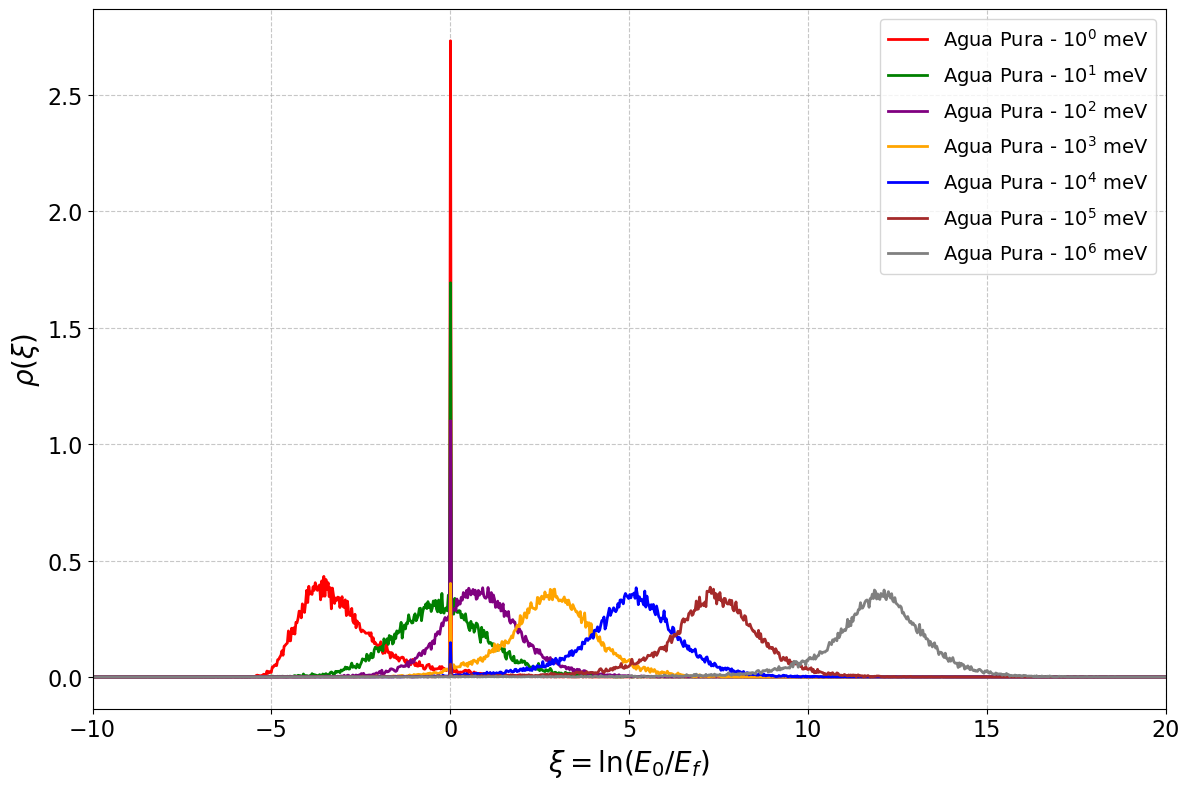

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # aquí seleccionas la COLUMNA (ej: col3 = índice 2)
                except:
                    continue
    data = np.array(data)
    data = data[~np.isnan(data)]  # quitar nan
    
    # Calcular histograma
    counts, bins = np.histogram(data, bins=bins, range=range, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Graficar como línea
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, label=label)

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../1meV/Agua-pura/cita-AP-termicos-1meV.txt", "red",    "Agua Pura - $10^{0}$ meV"),
    ("../10meV/Agua-pura/cita-10meV-AP.txt", "green", "Agua Pura - $10^{1}$ meV"),
    ("../100meV/Agua-pura/cita-100meV-AP.txt", "purple","Agua Pura - $10^{2}$ meV"),
    ("../1000meV/Agua-pura/cita-1000meV-AP.txt", "orange","Agua Pura - $10^{3}$ meV"),
    ("../10000meV/Agua-pura/cita-10000meV-AP.txt", "blue","Agua Pura - $10^{4}$ meV"),
    ("../100000meV/Agua-pura/cita-100000meV-AP.txt", "brown","Agua Pura - $10^{5}$ meV"),
    ("../1000000meV/Agua-pura/cita-1000000meV-AP.txt", "grey","Agua Pura - $10^{6}$ meV")
]

# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=1000, range=(-10,20), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)$", fontsize=20)
plt.ylabel(r"$\rho(\xi)$", fontsize=20)
plt.xlim(-10, 20)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=16)
plt.tick_params(axis='y', which='both', labelsize=16)
plt.legend(fontsize=14)

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-Agua-Pura.pdf", format="pdf")
plt.savefig("Cita-neutron-Agua-Pura.png", format="png")
plt.show()


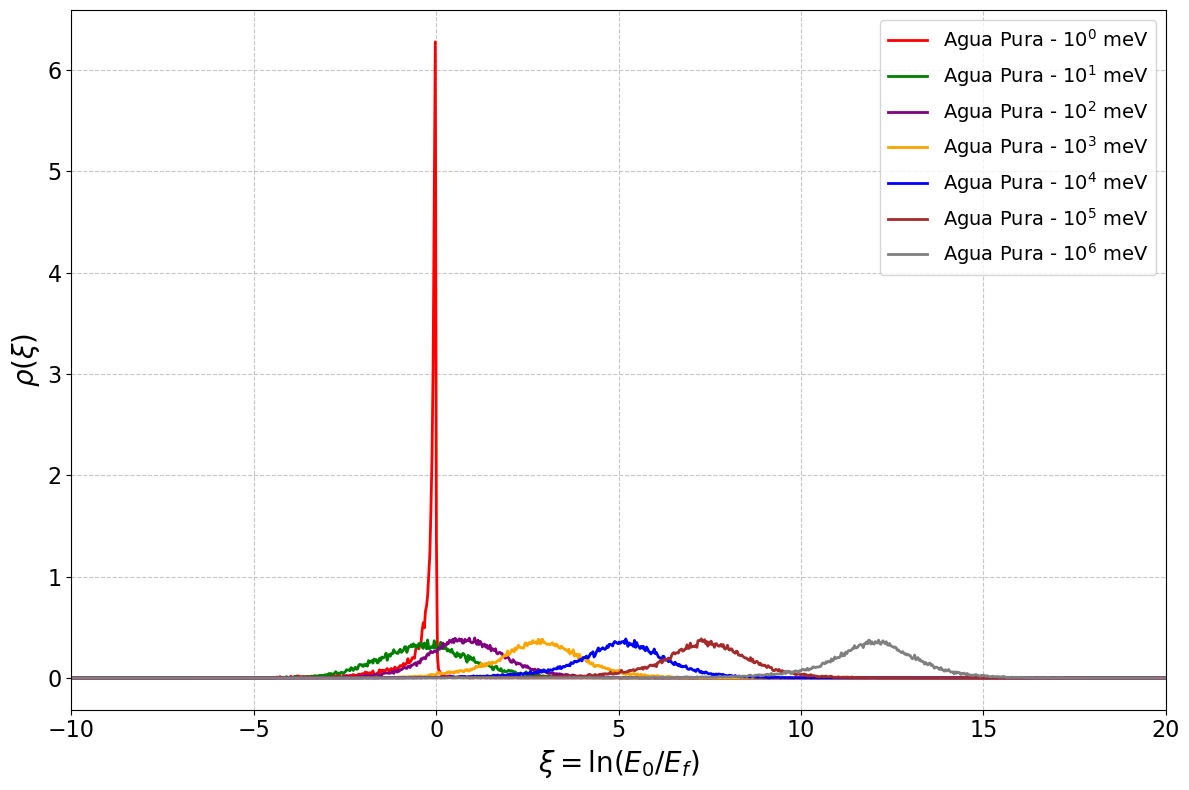

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]   # quitar NaN
    data = data[data != 0.0]       # quitar ceros

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular histograma
    counts, bins = np.histogram(data, bins=bins, range=range, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Graficar como línea
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, label=label)

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../1meV/Agua-pura/cita-AP-1meV.txt", "red",    "Agua Pura - $10^{0}$ meV"),
    ("../10meV/Agua-pura/cita-10meV-AP.txt", "green", "Agua Pura - $10^{1}$ meV"),
    ("../100meV/Agua-pura/cita-100meV-AP.txt", "purple","Agua Pura - $10^{2}$ meV"),
    ("../1000meV/Agua-pura/cita-1000meV-AP.txt", "orange","Agua Pura - $10^{3}$ meV"),
    ("../10000meV/Agua-pura/cita-10000meV-AP.txt", "blue","Agua Pura - $10^{4}$ meV"),
    ("../100000meV/Agua-pura/cita-100000meV-AP.txt", "brown","Agua Pura - $10^{5}$ meV"),
    ("../1000000meV/Agua-pura/cita-1000000meV-AP.txt", "grey","Agua Pura - $10^{6}$ meV")
]

# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=1000, range=(-10,20), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)$", fontsize=20)
plt.ylabel(r"$\rho(\xi)$", fontsize=20)
plt.xlim(-10, 20)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=16)
plt.tick_params(axis='y', which='both', labelsize=16)
plt.legend(fontsize=14)

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-Agua-Pura.pdf", format="pdf")
plt.savefig("Cita-neutron-Agua-Pura.png", format="png")
plt.show()


Agua Pura - $10^{0}$ meV: media = -0.3563, desviación estándar = 0.6493
Agua Pura - $2.5$ meV: media = -0.2401, desviación estándar = 0.4711
Agua Pura - $5$ meV: media = -0.1619, desviación estándar = 0.3610
Agua Pura - $7$ meV: media = -0.1205, desviación estándar = 0.3042
Agua Pura - $10^{1}$ meV: media = -0.0842, desviación estándar = 0.2610


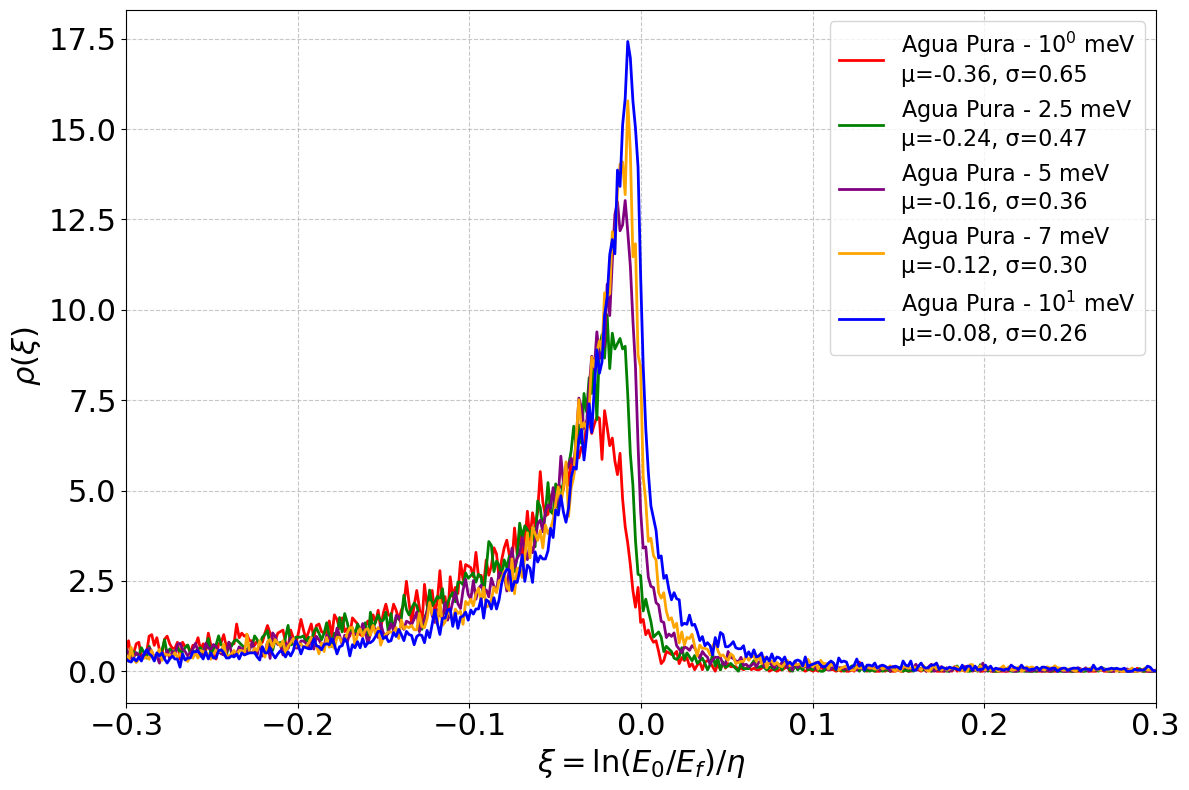

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]   # quitar NaN
    data = data[data != 0.0]       # quitar ceros

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular valores estadísticos
    mean_val = np.mean(data)
    std_val  = np.std(data)

    # Mostrar en consola
    print(f"{label}: media = {mean_val:.4f}, desviación estándar = {std_val:.4f}")

    # Calcular histograma
    counts, bins = np.histogram(data, bins=bins, range=range, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Graficar como línea
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, 
             label=f"{label}\nμ={mean_val:.2f}, σ={std_val:.2f}")

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../1meV/Agua-pura/cita-AP-1meV.txt", "red",    "Agua Pura - $10^{0}$ meV"),
    ("../2.5meV/Agua-pura/cita-AP-2-5meV.txt", "green", "Agua Pura - $2.5$ meV"),
    ("../5meV/Agua-pura/cita-AP-5meV.txt", "purple","Agua Pura - $5$ meV"),
    ("../7meV/Agua-pura/cita-AP-7meV.txt", "orange","Agua Pura - $7$ meV"),
    ("../10meV/Agua-pura/cita-AP-10meV.txt", "blue","Agua Pura - $10^{1}$ meV")
 ]





# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=20000, range=(-10,20), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)/\eta$", fontsize=22)
plt.ylabel(r"$\rho(\xi)$", fontsize=22)
plt.xlim(-0.3, 0.3)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=22)
plt.tick_params(axis='y', which='both', labelsize=22)
plt.legend(fontsize=16, loc="upper right")

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-frios-AP.pdf", format="pdf")
plt.savefig("Cita-neutron-frios-AP.png", format="png")
plt.show()


Agua Pura - $25$ meV: media = 0.0033, desviación estándar = 0.2070
Agua Pura - $50$ meV: media = 0.0562, desviación estándar = 0.1998
Agua Pura - $80$ meV: media = 0.0855, desviación estándar = 0.2167
Agua Pura - $10^{2}$ meV: media = 0.1008, desviación estándar = 0.2317
Agua Pura - $3\times 10^{2}$ meV: media = 0.1561, desviación estándar = 0.2694


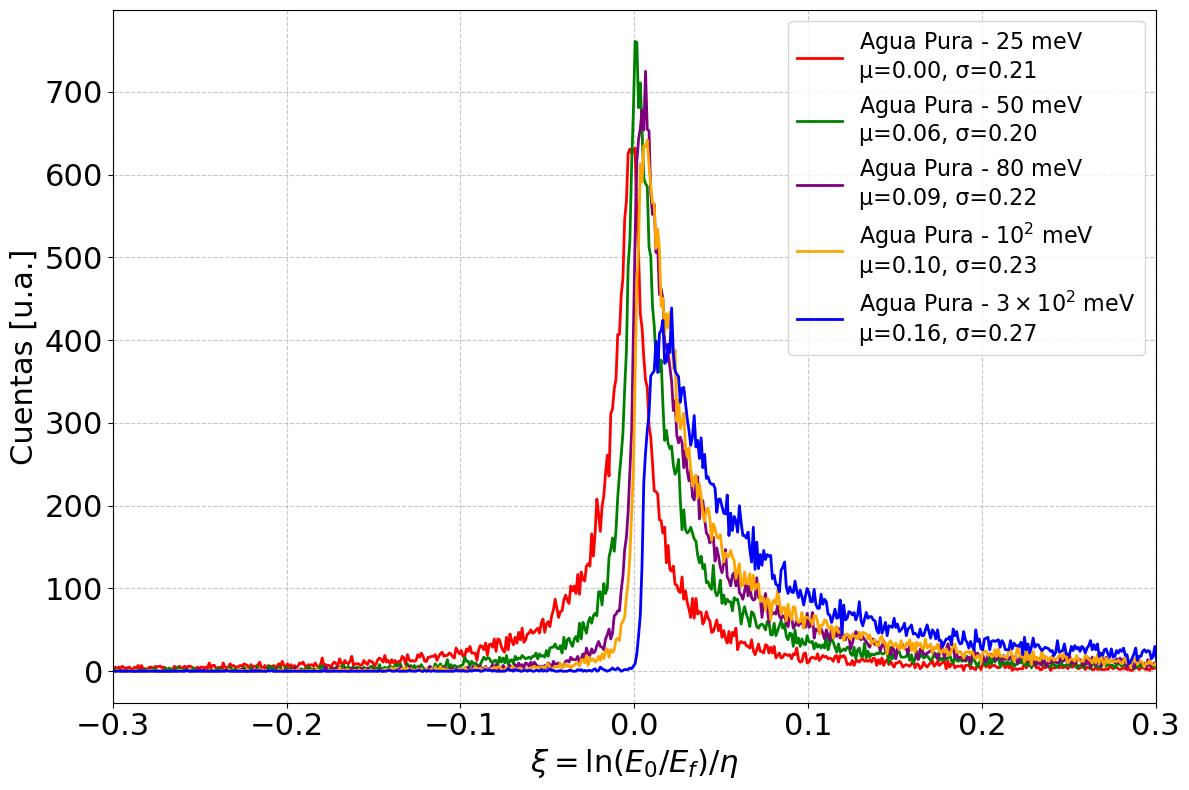

In [44]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia (sin densidad) ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]
    data = data[data != 0.0]

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular valores estadísticos
    mean_val = np.mean(data)
    std_val  = np.std(data)

    # Mostrar en consola
    print(f"{label}: media = {mean_val:.4f}, desviación estándar = {std_val:.4f}")

    # Calcular histograma (SIN normalizar)
    counts, bins = np.histogram(data, bins=bins, range=range, density=False)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Graficar como polígono (línea continua)
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, 
             label=f"{label}\nμ={mean_val:.2f}, σ={std_val:.2f}")

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../25meV/Agua-pura/cita-AP-25meV.txt", "red",    "Agua Pura - $25$ meV"),
    ("../50meV/Agua-pura/cita-AP-50meV.txt", "green", "Agua Pura - $50$ meV"),
    ("../80meV/Agua-pura/cita-AP-80meV.txt", "purple","Agua Pura - $80$ meV"),
    ("../100meV/Agua-pura/cita-AP-100meV.txt", "orange","Agua Pura - $10^{2}$ meV"),
    ("../300meV/Agua-pura/cita-AP-300meV.txt", "blue","Agua Pura - $3\\times 10^{2}$ meV")
]

# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=2000, range=(-1, 1), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)/\eta$", fontsize=22)
plt.ylabel("Cuentas [u.a.]", fontsize=22)
plt.xlim(-0.3, 0.3)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=22)
plt.tick_params(axis='y', which='both', labelsize=22)
plt.legend(fontsize=16, loc="upper right")

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-termicos-AP-poligono.pdf", format="pdf")
plt.savefig("Cita-neutron-termicos-AP-poligono.png", format="png")
plt.show()


# Histogramas agua + 2.5 % de sal

In [148]:
# Nombre del archivo de datos
archivo_datos = "../1meV/Agua+2.5NaCl/numero-dispersiones-elasticas-1meV-A-25NaCl.txt"
# Lista para almacenar los datos
datos_n_A_25NaCl_1meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_25NaCl_1meV.append(valor)

In [150]:
# Nombre del archivo de datos
archivo_datos = "../10meV/Agua+2.5NaCl/numero-dispersiones-elasticas-10meV-A-25NaCl.txt"
# Lista para almacenar los datos
datos_n_A_25NaCl_10meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_25NaCl_10meV.append(valor)

In [152]:
# Nombre del archivo de datos
archivo_datos = "../100meV/Agua+2.5NaCl/numero-dispersiones-elasticas-100meV-A-25NaCl.txt"
# Lista para almacenar los datos
datos_n_A_25NaCl_100meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_25NaCl_100meV.append(valor)

In [154]:
# Nombre del archivo de datos
archivo_datos = "../1000meV/Agua+2.5NaCl/numero-dispersiones-elasticas-1000meV-A-25NaCl.txt"
# Lista para almacenar los datos
datos_n_A_25NaCl_1000meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_25NaCl_1000meV.append(valor)

In [156]:
# Nombre del archivo de datos
archivo_datos = "../10000meV/Agua+2.5NaCl/numero-dispersiones-elasticas-10000meV-A-25NaCl.txt"
# Lista para almacenar los datos
datos_n_A_25NaCl_10000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_25NaCl_10000meV.append(valor)

In [158]:
# Nombre del archivo de datos
archivo_datos = "../100000meV/Agua+2.5NaCl/numero-dispersiones-elasticas-100000meV-A-25NaCl.txt"
# Lista para almacenar los datos
datos_n_A_25NaCl_100000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_25NaCl_100000meV.append(valor)

In [160]:
# Nombre del archivo de datos
archivo_datos = "../1000000meV/Agua+2.5NaCl/numero-dispersiones-elasticas-1000000meV-A-25NaCl.txt"
# Lista para almacenar los datos
datos_n_A_25NaCl_1000000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_25NaCl_1000000meV.append(valor)

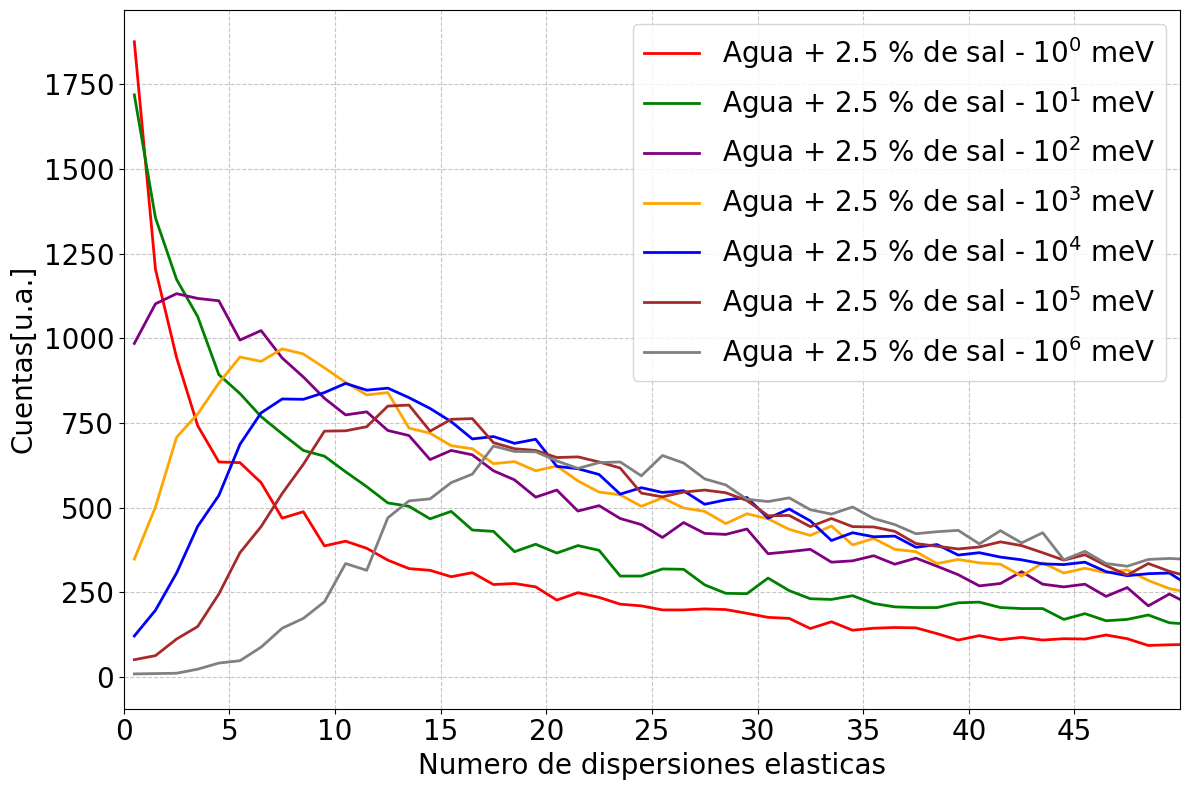

In [250]:
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.lines import Line2D

# Definir número de bins y rango
numero_bins = 300
inicio, fin = 0, 300

# Función para calcular y graficar polígonos de frecuencia como línea continua
def plot_polygon(data, color, label):
    # Obtener histogram data
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    
    # Calcular el punto medio de cada bin
    bin_centers = (bins[:-1] + bins[1:]) / 2  
    
    # Graficar solo la línea continua (sin puntos)
    plt.plot(bin_centers, counts, linestyle='-', color=color, label=label, linewidth=2)

# Crear figura
plt.figure(figsize=(12, 8))

# Graficar los datos como polígonos de frecuencia (líneas continuas)
plot_polygon(datos_n_A_25NaCl_1meV, color='red', label='Agua + 2.5 % de sal - $10^{0}$ meV')
plot_polygon(datos_n_A_25NaCl_10meV, color='green', label='Agua + 2.5 % de sal - $10^{1}$ meV')
plot_polygon(datos_n_A_25NaCl_100meV, color='purple', label='Agua + 2.5 % de sal - $10^{2}$ meV')
plot_polygon(datos_n_A_25NaCl_1000meV, color='orange', label='Agua + 2.5 % de sal - $10^{3}$ meV')
plot_polygon(datos_n_A_25NaCl_10000meV, color='blue', label='Agua + 2.5 % de sal - $10^{4}$ meV')
plot_polygon(datos_n_A_25NaCl_100000meV, color='brown', label='Agua + 2.5 % de sal - $10^{5}$ meV')
plot_polygon(datos_n_A_25NaCl_1000000meV, color='grey', label='Agua + 2.5 % de sal - $10^{6}$ meV')

# Agregar etiquetas y formato
plt.xlabel('Numero de dispersiones elasticas', fontsize=20)
plt.ylabel('Cuentas[u.a.]', fontsize=20)
#plt.yscale('log')  # Escala logarítmica
plt.xlim(0, 50)
plt.xticks(np.arange(0, 50, 5))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=20)  # Tics mayores
# Agregar leyenda
plt.legend(fontsize=20)

# Guardar y mostrar
plt.tight_layout()
plt.savefig('numero-dispersion-elastica-neutron-Agua-25NaCl.jpg', format='jpg')
plt.savefig('numero-dispersion-elastica-neutron-Agua-25NaCl.pdf', format='pdf')
plt.show()



# Histogramas agua + 2.5 % de NaCl (Cita)

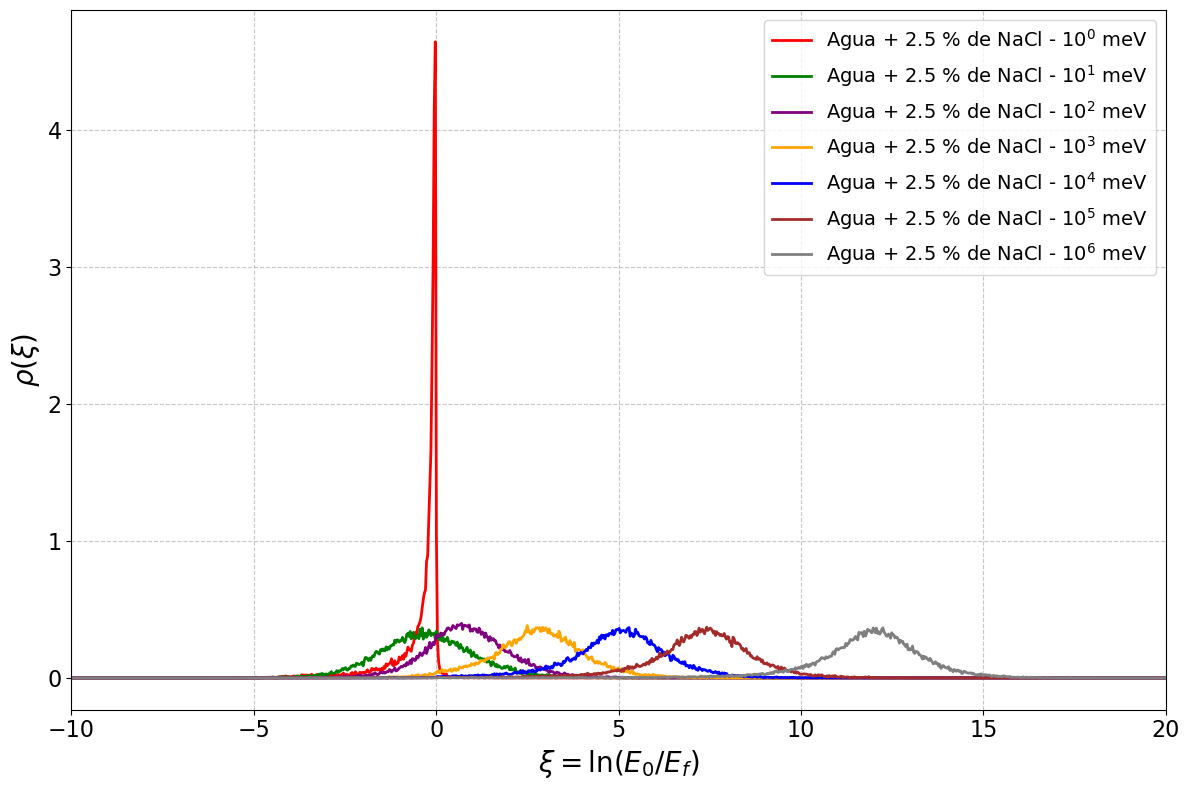

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]   # quitar NaN
    data = data[data != 0.0]       # quitar ceros

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular histograma
    counts, bins = np.histogram(data, bins=bins, range=range, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Graficar como línea
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, label=label)

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../1meV/Agua+2.5NaCl/cita-A-25NaCl-1meV.txt", "red",    "Agua + 2.5 % de NaCl - $10^{0}$ meV"),
    ("../10meV/Agua+2.5NaCl/cita-10meV-A-25NaCl.txt", "green", "Agua + 2.5 % de NaCl - $10^{1}$ meV"),
    ("../100meV/Agua+2.5NaCl/cita-100meV-A-25NaCl.txt", "purple","Agua + 2.5 % de NaCl - $10^{2}$ meV"),
    ("../1000meV/Agua+2.5NaCl/cita-1000meV-A-25NaCl.txt", "orange","Agua + 2.5 % de NaCl - $10^{3}$ meV"),
    ("../10000meV/Agua+2.5NaCl/cita-10000meV-A-25NaCl.txt", "blue","Agua + 2.5 % de NaCl - $10^{4}$ meV"),
    ("../100000meV/Agua+2.5NaCl/cita-100000meV-A-25NaCl.txt", "brown","Agua + 2.5 % de NaCl - $10^{5}$ meV"),
    ("../1000000meV/Agua+2.5NaCl/cita-1000000meV-A-25NaCl.txt", "grey","Agua + 2.5 % de NaCl - $10^{6}$ meV")
]

# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=1000, range=(-10,20), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)$", fontsize=20)
plt.ylabel(r"$\rho(\xi)$", fontsize=20)
plt.xlim(-10, 20)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=16)
plt.tick_params(axis='y', which='both', labelsize=16)
plt.legend(fontsize=14)

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-Agua-25NaCl.pdf", format="pdf")
plt.savefig("Cita-neutron-Agua-25NaCl.png", format="png")
plt.show()


Agua + 2.5 % de NaCl - $10^{0}$ meV: media = -0.4157, desviación estándar = 0.7009
Agua + 2.5 % de NaCl - $2.5$ meV: media = -0.2782, desviación estándar = 0.5065
Agua + 2.5 % de NaCl - $5$ meV: media = -0.1809, desviación estándar = 0.3768
Agua + 2.5 % de NaCl - $7$ meV: media = -0.1399, desviación estándar = 0.3259
Agua + 2.5 % de NaCl - $10^{1}$ meV: media = -0.0939, desviación estándar = 0.2825


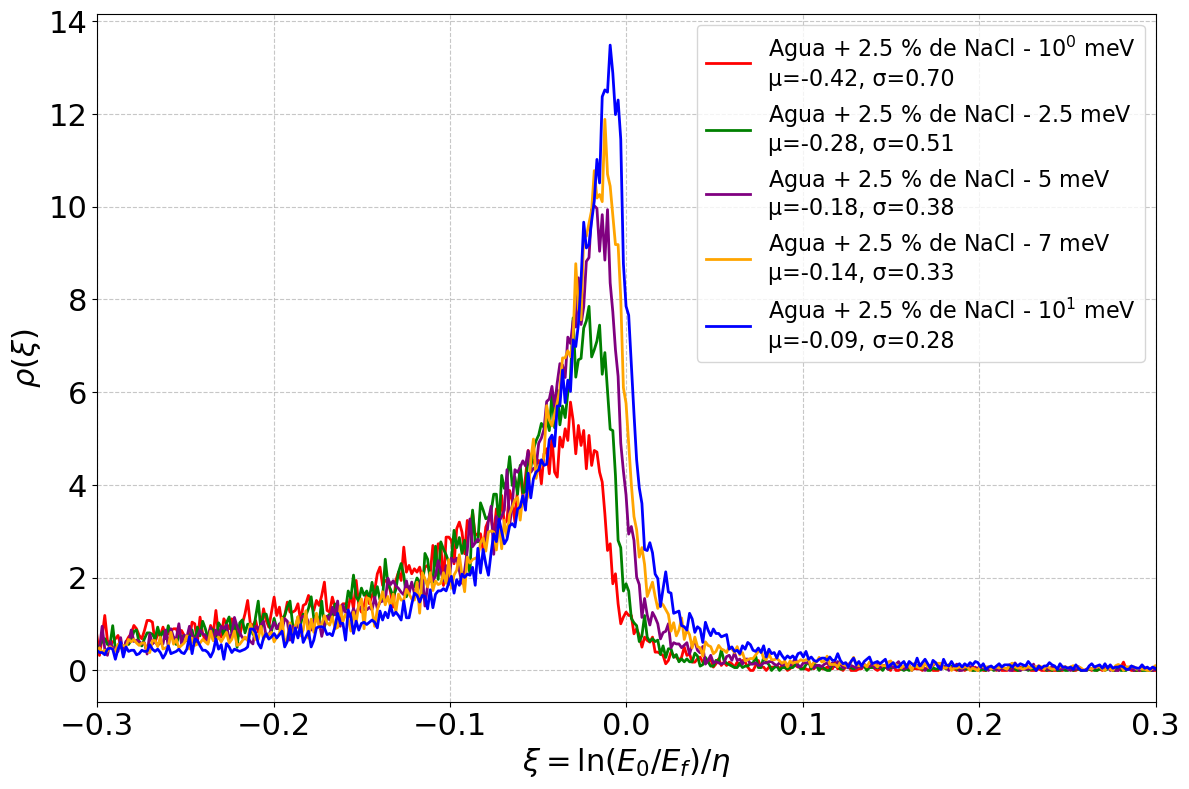

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]   # quitar NaN
    data = data[data != 0.0]       # quitar ceros

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular valores estadísticos
    mean_val = np.mean(data)
    std_val  = np.std(data)

    # Mostrar en consola
    print(f"{label}: media = {mean_val:.4f}, desviación estándar = {std_val:.4f}")

    # Calcular histograma
    counts, bins = np.histogram(data, bins=bins, range=range, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Graficar como línea
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, 
             label=f"{label}\nμ={mean_val:.2f}, σ={std_val:.2f}")

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../1meV/Agua+2.5NaCl/cita-A-25NaCl-1meV.txt", "red",    "Agua + 2.5 % de NaCl - $10^{0}$ meV"),
    ("../2.5meV/Agua+2.5NaCl/cita-A-25NaCl-2-5meV.txt", "green", "Agua + 2.5 % de NaCl - $2.5$ meV"),
    ("../5meV/Agua+2.5NaCl/cita-A-25NaCl-5meV.txt", "purple","Agua + 2.5 % de NaCl - $5$ meV"),
    ("../7meV/Agua+2.5NaCl/cita-A-25NaCl-7meV.txt", "orange","Agua + 2.5 % de NaCl - $7$ meV"),
    ("../10meV/Agua+2.5NaCl/cita-A-25NaCl-10meV.txt", "blue","Agua + 2.5 % de NaCl - $10^{1}$ meV")

]





# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=20000, range=(-10,20), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)/\eta$", fontsize=22)
plt.ylabel(r"$\rho(\xi)$", fontsize=22)
plt.xlim(-0.3, 0.3)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=22)
plt.tick_params(axis='y', which='both', labelsize=22)
plt.legend(fontsize=16, loc="upper right")

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-frios-25NaCl.pdf", format="pdf")
plt.savefig("Cita-neutron-frios-25NaCl.png", format="png")
plt.show()


Agua + 2.5 % de NaCl - $25$ meV: media = 0.0044, desviación estándar = 0.2238
Agua + 2.5 % de NaCl - $50$ meV: media = 0.0673, desviación estándar = 0.2266
Agua + 2.5 % de NaCl - $80$ meV: media = 0.1009, desviación estándar = 0.2350
Agua + 2.5 % de NaCl - $10^{2}$ meV: media = 0.1168, desviación estándar = 0.2514
Agua + 2.5 % de NaCl - $3 \times 10^{2}$ meV: media = 0.1785, desviación estándar = 0.2856


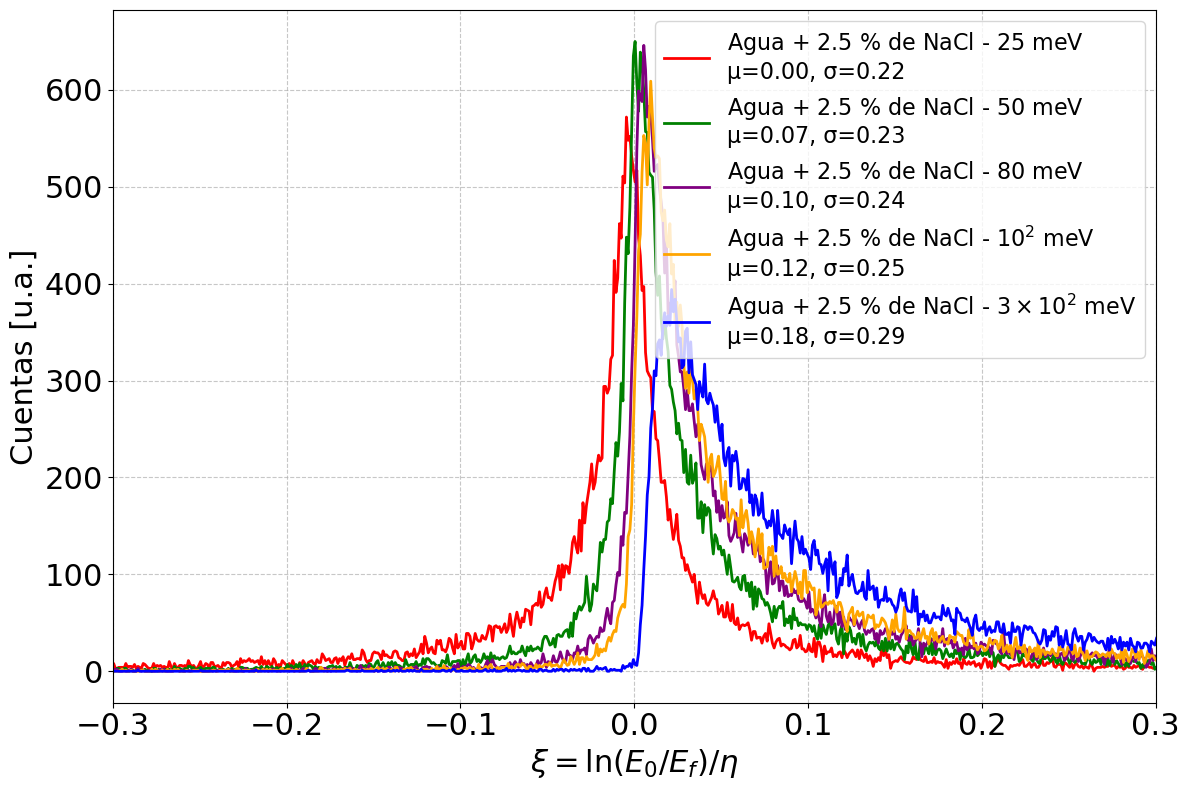

In [46]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia (sin densidad) ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]
    data = data[data != 0.0]

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular valores estadísticos
    mean_val = np.mean(data)
    std_val  = np.std(data)

    # Mostrar en consola
    print(f"{label}: media = {mean_val:.4f}, desviación estándar = {std_val:.4f}")

    # Calcular histograma (SIN normalizar)
    counts, bins = np.histogram(data, bins=bins, range=range, density=False)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Graficar como polígono (línea continua)
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, 
             label=f"{label}\nμ={mean_val:.2f}, σ={std_val:.2f}")

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../25meV/Agua+2.5NaCl/cita-A-25NaCl-25meV.txt", "red",    "Agua + 2.5 % de NaCl - $25$ meV"),
    ("../50meV/Agua+2.5NaCl/cita-A-25NaCl-50meV.txt", "green", "Agua + 2.5 % de NaCl - $50$ meV"),
    ("../80meV/Agua+2.5NaCl/cita-A-25NaCl-80meV.txt", "purple","Agua + 2.5 % de NaCl - $80$ meV"),
    ("../100meV/Agua+2.5NaCl/cita-A-25NaCl-100meV.txt", "orange","Agua + 2.5 % de NaCl - $10^{2}$ meV"),
    ("../300meV/Agua+2.5NaCl/cita-A-25NaCl-300meV.txt", "blue","Agua + 2.5 % de NaCl - $3 \\times 10^{2}$ meV")
]

# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=2000, range=(-1, 1), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)/\eta$", fontsize=22)
plt.ylabel("Cuentas [u.a.]", fontsize=22)
plt.xlim(-0.3, 0.3)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=22)
plt.tick_params(axis='y', which='both', labelsize=22)
plt.legend(fontsize=16, loc="upper right")

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-termicos-A-25NaCl-poligono.pdf", format="pdf")
plt.savefig("Cita-neutron-termicos-A-25NaCl-poligono.png", format="png")
plt.show()


# Histogramas agua + 5 % de sal

In [180]:
# Nombre del archivo de datos
archivo_datos = "../1meV/Agua+5NaCl/numero-dispersiones-elasticas-1meV-A-5NaCl.txt"
# Lista para almacenar los datos
datos_n_A_5NaCl_1meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_5NaCl_1meV.append(valor)

In [182]:
# Nombre del archivo de datos
archivo_datos = "../10meV/Agua+5NaCl/numero-dispersiones-elasticas-10meV-A-5NaCl.txt"
# Lista para almacenar los datos
datos_n_A_5NaCl_10meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_5NaCl_10meV.append(valor)

In [184]:
# Nombre del archivo de datos
archivo_datos = "../100meV/Agua+5NaCl/numero-dispersiones-elasticas-100meV-A-5NaCl.txt"
# Lista para almacenar los datos
datos_n_A_5NaCl_100meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_5NaCl_100meV.append(valor)

In [186]:
# Nombre del archivo de datos
archivo_datos = "../1000meV/Agua+5NaCl/numero-dispersiones-elasticas-1000meV-A-5NaCl.txt"
# Lista para almacenar los datos
datos_n_A_5NaCl_1000meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_5NaCl_1000meV.append(valor)

In [188]:
# Nombre del archivo de datos
archivo_datos = "../10000meV/Agua+5NaCl/numero-dispersiones-elasticas-10000meV-A-5NaCl.txt"
# Lista para almacenar los datos
datos_n_A_5NaCl_10000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_5NaCl_10000meV.append(valor)

In [190]:
# Nombre del archivo de datos
archivo_datos = "../100000meV/Agua+5NaCl/numero-dispersiones-elasticas-100000meV-A-5NaCl.txt"
# Lista para almacenar los datos
datos_n_A_5NaCl_100000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_5NaCl_100000meV.append(valor)

In [192]:
# Nombre del archivo de datos
archivo_datos = "../1000000meV/Agua+5NaCl/numero-dispersiones-elasticas-1000000meV-A-5NaCl.txt"
# Lista para almacenar los datos
datos_n_A_5NaCl_1000000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_5NaCl_1000000meV.append(valor)

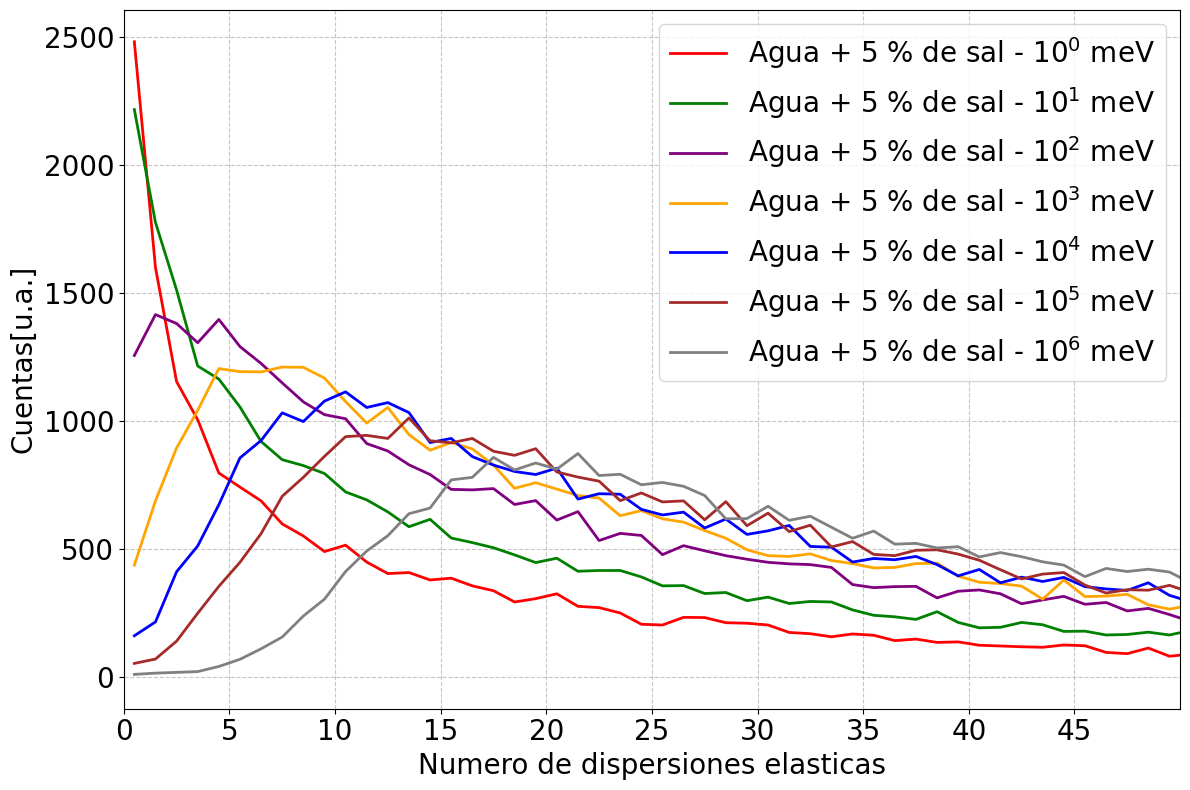

In [254]:
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.lines import Line2D

# Definir número de bins y rango
numero_bins = 200
inicio, fin = 0, 200

# Función para calcular y graficar polígonos de frecuencia como línea continua
def plot_polygon(data, color, label):
    # Obtener histogram data
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    
    # Calcular el punto medio de cada bin
    bin_centers = (bins[:-1] + bins[1:]) / 2  
    
    # Graficar solo la línea continua (sin puntos)
    plt.plot(bin_centers, counts, linestyle='-', color=color, label=label, linewidth=2)

# Crear figura
plt.figure(figsize=(12, 8))

# Graficar los datos como polígonos de frecuencia (líneas continuas)
plot_polygon(datos_n_A_5NaCl_1meV, color='red', label='Agua + 5 % de sal - $10^{0}$ meV')
plot_polygon(datos_n_A_5NaCl_10meV, color='green', label='Agua + 5 % de sal - $10^{1}$ meV')
plot_polygon(datos_n_A_5NaCl_100meV, color='purple', label='Agua + 5 % de sal - $10^{2}$ meV')
plot_polygon(datos_n_A_5NaCl_1000meV, color='orange', label='Agua + 5 % de sal - $10^{3}$ meV')
plot_polygon(datos_n_A_5NaCl_10000meV, color='blue', label='Agua + 5 % de sal - $10^{4}$ meV')
plot_polygon(datos_n_A_5NaCl_100000meV, color='brown', label='Agua + 5 % de sal - $10^{5}$ meV')
plot_polygon(datos_n_A_5NaCl_1000000meV, color='grey', label='Agua + 5 % de sal - $10^{6}$ meV')

# Agregar etiquetas y formato
plt.xlabel('Numero de dispersiones elasticas', fontsize=20)
plt.ylabel('Cuentas[u.a.]', fontsize=20)
#plt.yscale('log')  # Escala logarítmica
plt.xlim(0, 50)
plt.xticks(np.arange(0, 50, 5))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=20)  # Tics mayores
# Agregar leyenda
plt.legend(fontsize=20)

# Guardar y mostrar
plt.tight_layout()
plt.savefig('numero-dispersion-elastica-neutron-Agua-5NaCl.jpg', format='jpg')
plt.savefig('numero-dispersion-elastica-neutron-Agua-5NaCl.pdf', format='pdf')
plt.show()



In [ ]:
# Histogramas agua + 5 % de NaCl (Cita)

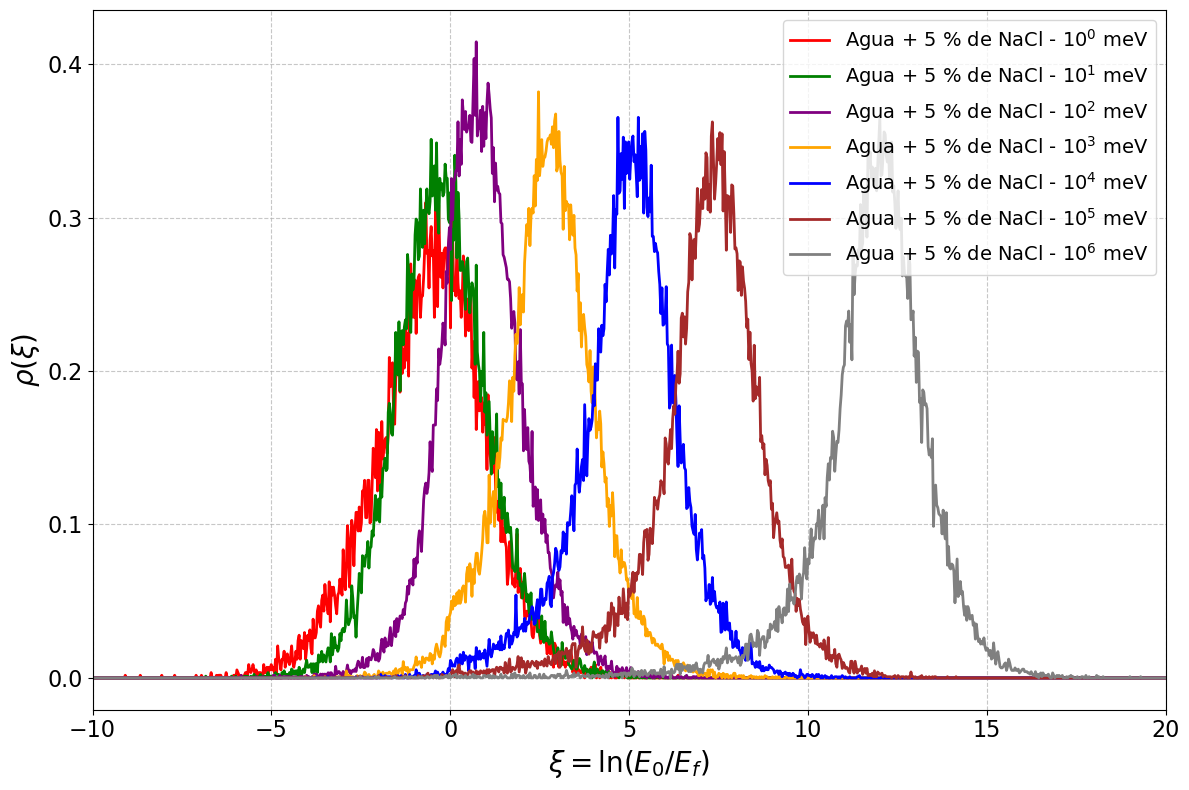

In [199]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]   # quitar NaN
    data = data[data != 0.0]       # quitar ceros

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular histograma
    counts, bins = np.histogram(data, bins=bins, range=range, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Graficar como línea
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, label=label)

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../1meV/Agua+5NaCl/cita-1meV-A-5NaCl.txt", "red",    "Agua + 5 % de NaCl - $10^{0}$ meV"),
    ("../10meV/Agua+5NaCl/cita-10meV-A-5NaCl.txt", "green", "Agua + 5 % de NaCl - $10^{1}$ meV"),
    ("../100meV/Agua+5NaCl/cita-100meV-A-5NaCl.txt", "purple","Agua + 5 % de NaCl - $10^{2}$ meV"),
    ("../1000meV/Agua+5NaCl/cita-1000meV-A-5NaCl.txt", "orange","Agua + 5 % de NaCl - $10^{3}$ meV"),
    ("../10000meV/Agua+5NaCl/cita-10000meV-A-5NaCl.txt", "blue","Agua + 5 % de NaCl - $10^{4}$ meV"),
    ("../100000meV/Agua+5NaCl/cita-100000meV-A-5NaCl.txt", "brown","Agua + 5 % de NaCl - $10^{5}$ meV"),
    ("../1000000meV/Agua+5NaCl/cita-1000000meV-A-5NaCl.txt", "grey","Agua + 5 % de NaCl - $10^{6}$ meV")
]

# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=1000, range=(-10,20), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)$", fontsize=20)
plt.ylabel(r"$\rho(\xi)$", fontsize=20)
plt.xlim(-10, 20)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=16)
plt.tick_params(axis='y', which='both', labelsize=16)
plt.legend(fontsize=14)

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-Agua-5NaCl.pdf", format="pdf")
plt.savefig("Cita-neutron-Agua-5NaCl.png", format="png")
plt.show()


Agua + 5 % de NaCl - $10^{0}$ meV: media = -0.4671, desviación estándar = 0.7490
Agua + 5 % de NaCl - $2.5$ meV: media = -0.3140, desviación estándar = 0.5370
Agua + 5 % de NaCl - $5$ meV: media = -0.2019, desviación estándar = 0.3989
Agua + 5 % de NaCl - $7$ meV: media = -0.1526, desviación estándar = 0.3516
Agua + 5 % de NaCl - $10^{0}$ meV: media = -0.1019, desviación estándar = 0.3078


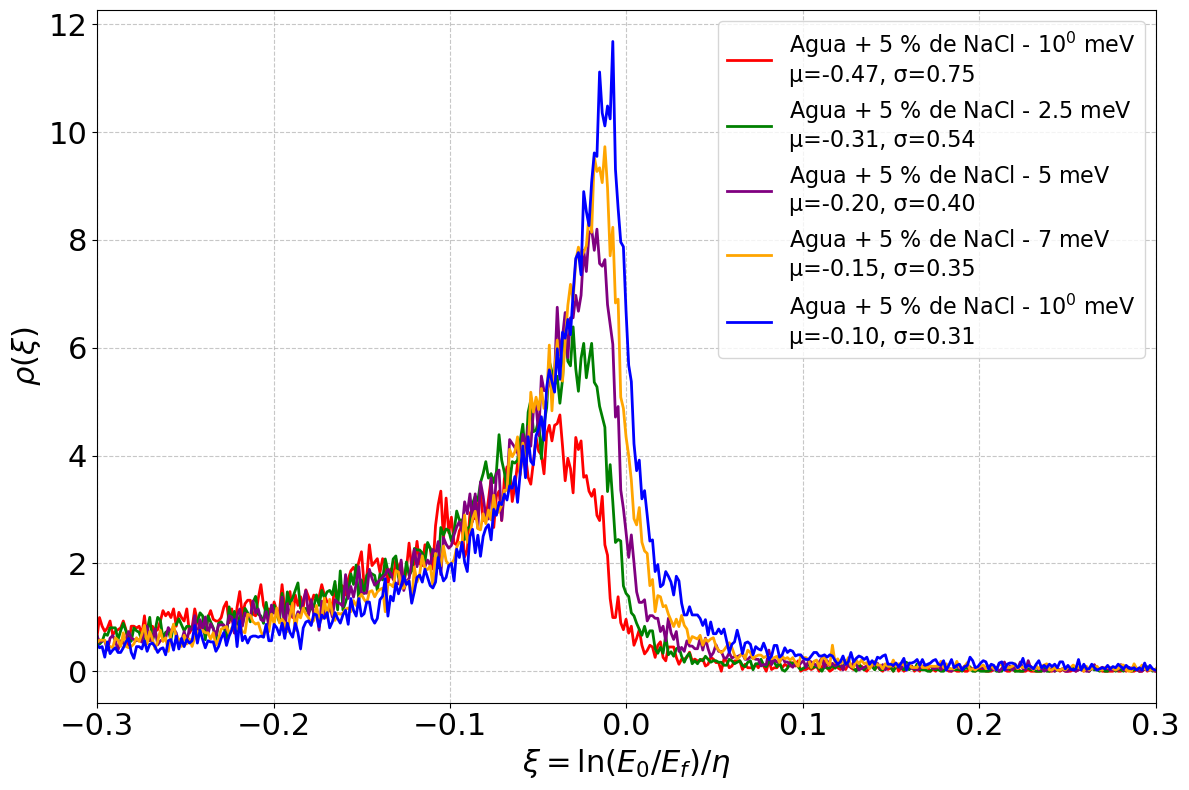

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]   # quitar NaN
    data = data[data != 0.0]       # quitar ceros

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular valores estadísticos
    mean_val = np.mean(data)
    std_val  = np.std(data)

    # Mostrar en consola
    print(f"{label}: media = {mean_val:.4f}, desviación estándar = {std_val:.4f}")

    # Calcular histograma
    counts, bins = np.histogram(data, bins=bins, range=range, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Graficar como línea
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, 
             label=f"{label}\nμ={mean_val:.2f}, σ={std_val:.2f}")

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../1meV/Agua+5NaCl/cita-A-5NaCl-1meV.txt", "red",    "Agua + 5 % de NaCl - $10^{0}$ meV"),
    ("../2.5meV/Agua+5NaCl/cita-A-5NaCl-2-5meV.txt", "green", "Agua + 5 % de NaCl - $2.5$ meV"),
    ("../5meV/Agua+5NaCl/cita-A-5NaCl-5meV.txt", "purple","Agua + 5 % de NaCl - $5$ meV"),
    ("../7meV/Agua+5NaCl/cita-A-5NaCl-7meV.txt", "orange","Agua + 5 % de NaCl - $7$ meV"),
    ("../10meV/Agua+5NaCl/cita-A-5NaCl-10meV.txt", "blue","Agua + 5 % de NaCl - $10^{0}$ meV")
]





# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=20000, range=(-10,20), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)/\eta$", fontsize=22)
plt.ylabel(r"$\rho(\xi)$", fontsize=22)
plt.xlim(-0.3, 0.3)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=22)
plt.tick_params(axis='y', which='both', labelsize=22)
plt.legend(fontsize=16, loc="upper right")

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-frios-5NaCl.pdf", format="pdf")
plt.savefig("Cita-neutron-frios-5NaCl.png", format="png")
plt.show()


Agua + 5 % de NaCl - $25$ meV: media = 0.0083, desviación estándar = 0.2387
Agua + 5 % de NaCl - $50$ meV: media = 0.0714, desviación estándar = 0.2352
Agua + 5 % de NaCl - $80$ meV: media = 0.1114, desviación estándar = 0.2503
Agua + 5 % de NaCl - $10^{2}$ meV: media = 0.1297, desviación estándar = 0.2648
Agua + 5 % de NaCl - $3\times 10^{2}$ meV: media = 0.1995, desviación estándar = 0.3029


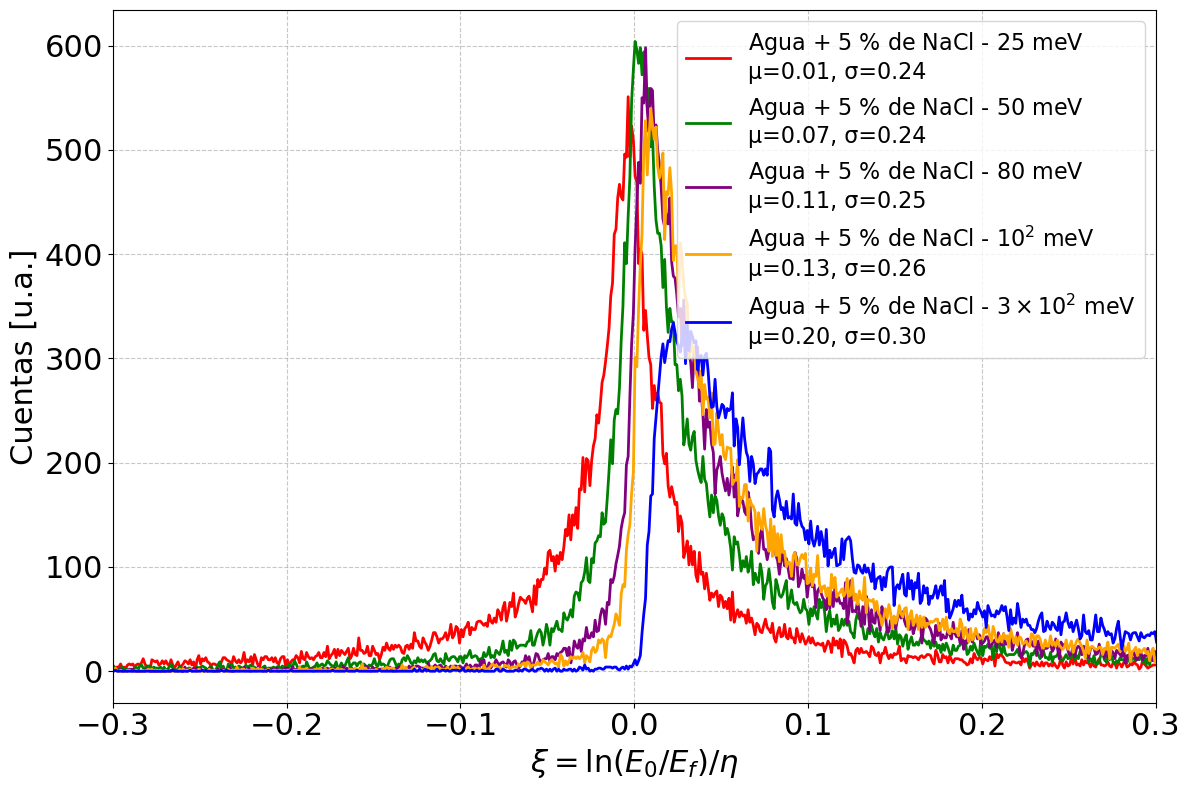

In [50]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia (sin densidad) ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]
    data = data[data != 0.0]

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular valores estadísticos
    mean_val = np.mean(data)
    std_val  = np.std(data)

    # Mostrar en consola
    print(f"{label}: media = {mean_val:.4f}, desviación estándar = {std_val:.4f}")

    # Calcular histograma (SIN normalizar)
    counts, bins = np.histogram(data, bins=bins, range=range, density=False)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Graficar como polígono (línea continua)
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, 
             label=f"{label}\nμ={mean_val:.2f}, σ={std_val:.2f}")

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../25meV/Agua+5NaCl/cita-A-5NaCl-25meV.txt", "red",    "Agua + 5 % de NaCl - $25$ meV"),
    ("../50meV/Agua+5NaCl/cita-A-5NaCl-50meV.txt", "green", "Agua + 5 % de NaCl - $50$ meV"),
    ("../80meV/Agua+5NaCl/cita-A-5NaCl-80meV.txt", "purple","Agua + 5 % de NaCl - $80$ meV"),
    ("../100meV/Agua+5NaCl/cita-A-5NaCl-100meV.txt", "orange","Agua + 5 % de NaCl - $10^{2}$ meV"),
    ("../300meV/Agua+5NaCl/cita-A-5NaCl-300meV.txt", "blue","Agua + 5 % de NaCl - $3\\times 10^{2}$ meV")
]

# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=2000, range=(-1, 1), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)/\eta$", fontsize=22)
plt.ylabel("Cuentas [u.a.]", fontsize=22)
plt.xlim(-0.3, 0.3)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=22)
plt.tick_params(axis='y', which='both', labelsize=22)
plt.legend(fontsize=16, loc="upper right")

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-termicos-A-5NaCl-poligono.pdf", format="pdf")
plt.savefig("Cita-neutron-termicos-A-5NaCl-poligono.png", format="png")
plt.show()


# Histogramas agua + 10 % de sal

In [201]:
# Nombre del archivo de datos
archivo_datos = "../1meV/Agua+10NaCl/numero-dispersiones-elasticas-1meV-A-10NaCl.txt"
# Lista para almacenar los datos
datos_n_A_10NaCl_1meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_10NaCl_1meV.append(valor)

In [203]:
# Nombre del archivo de datos
archivo_datos = "../10meV/Agua+10NaCl/numero-dispersiones-elasticas-10meV-A-10NaCl.txt"
# Lista para almacenar los datos
datos_n_A_10NaCl_10meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_10NaCl_10meV.append(valor)

In [205]:
# Nombre del archivo de datos
archivo_datos = "../100meV/Agua+10NaCl/numero-dispersiones-elasticas-100meV-A-10NaCl.txt"
# Lista para almacenar los datos
datos_n_A_10NaCl_100meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_10NaCl_100meV.append(valor)

In [207]:
# Nombre del archivo de datos
archivo_datos = "../1000meV/Agua+10NaCl/numero-dispersiones-elasticas-1000meV-A-10NaCl.txt"
# Lista para almacenar los datos
datos_n_A_10NaCl_1000meV = []
# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_10NaCl_1000meV.append(valor)

In [220]:
# Nombre del archivo de datos
archivo_datos = "../10000meV/Agua+10NaCl/numero-dispersiones-elasticas-10000meV-A-10NaCl.txt"
# Lista para almacenar los datos
datos_n_A_10NaCl_10000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_10NaCl_10000meV.append(valor)

In [222]:
# Nombre del archivo de datos
archivo_datos = "../100000meV/Agua+10NaCl/numero-dispersiones-elasticas-100000meV-A-10NaCl.txt"
# Lista para almacenar los datos
datos_n_A_10NaCl_100000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_10NaCl_100000meV.append(valor)

In [213]:
# Nombre del archivo de datos
archivo_datos = "../1000000meV/Agua+10NaCl/numero-dispersiones-elasticas-1000000meV-A-10NaCl.txt"
# Lista para almacenar los datos
datos_n_A_10NaCl_1000000meV = []

# Abrir el archivo y leer los datos
with open(archivo_datos, 'r') as archivo:
    for linea in archivo:
        #Cada línea contiene un solo número en formato de texto
        valor = float(linea.strip())  # Convierte el texto a un número de punto flotante
        datos_n_A_10NaCl_1000000meV.append(valor)

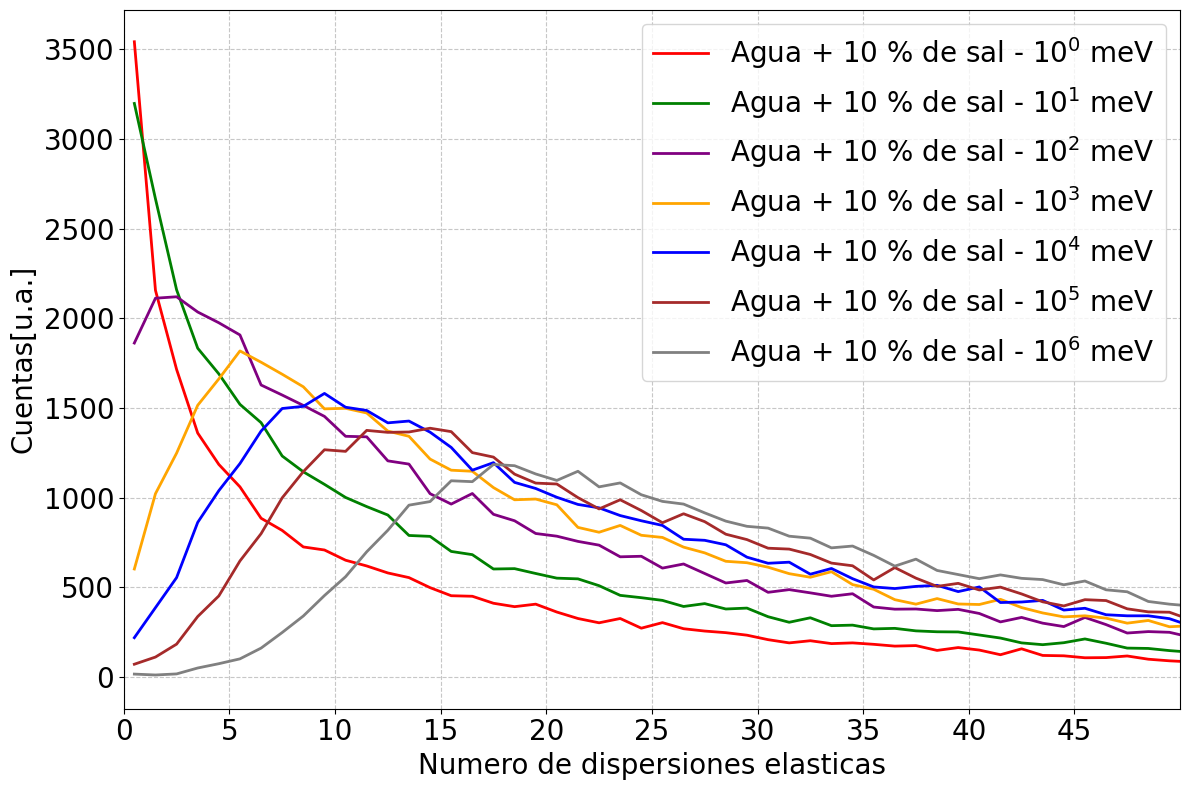

In [256]:
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.lines import Line2D

# Definir número de bins y rango
numero_bins = 200
inicio, fin = 0, 200

# Función para calcular y graficar polígonos de frecuencia como línea continua
def plot_polygon(data, color, label):
    # Obtener histogram data
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    
    # Calcular el punto medio de cada bin
    bin_centers = (bins[:-1] + bins[1:]) / 2  
    
    # Graficar solo la línea continua (sin puntos)
    plt.plot(bin_centers, counts, linestyle='-', color=color, label=label, linewidth=2)

# Crear figura
plt.figure(figsize=(12, 8))

# Graficar los datos como polígonos de frecuencia (líneas continuas)
plot_polygon(datos_n_A_10NaCl_1meV, color='red', label='Agua + 10 % de sal - $10^{0}$ meV')
plot_polygon(datos_n_A_10NaCl_10meV, color='green', label='Agua + 10 % de sal - $10^{1}$ meV')
plot_polygon(datos_n_A_10NaCl_100meV, color='purple', label='Agua + 10 % de sal - $10^{2}$ meV')
plot_polygon(datos_n_A_10NaCl_1000meV, color='orange', label='Agua + 10 % de sal - $10^{3}$ meV')
plot_polygon(datos_n_A_10NaCl_10000meV, color='blue', label='Agua + 10 % de sal - $10^{4}$ meV')
plot_polygon(datos_n_A_10NaCl_100000meV, color='brown', label='Agua + 10 % de sal - $10^{5}$ meV')
plot_polygon(datos_n_A_10NaCl_1000000meV, color='grey', label='Agua + 10 % de sal - $10^{6}$ meV')

# Agregar etiquetas y formato
plt.xlabel('Numero de dispersiones elasticas', fontsize=20)
plt.ylabel('Cuentas[u.a.]', fontsize=20)
#plt.yscale('log')  # Escala logarítmica
plt.xlim(0, 50)
plt.xticks(np.arange(0, 50, 5))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=20)  # Tics mayores
# Agregar leyenda
plt.legend(fontsize=20)

# Guardar y mostrar
plt.tight_layout()
plt.savefig('numero-dispersion-elastica-neutron-Agua-10NaCl.jpg', format='jpg')
plt.savefig('numero-dispersion-elastica-neutron-Agua-10NaCl.pdf', format='pdf')
plt.show()



# Histogramas agua + 10 % de NaCl (Cita)

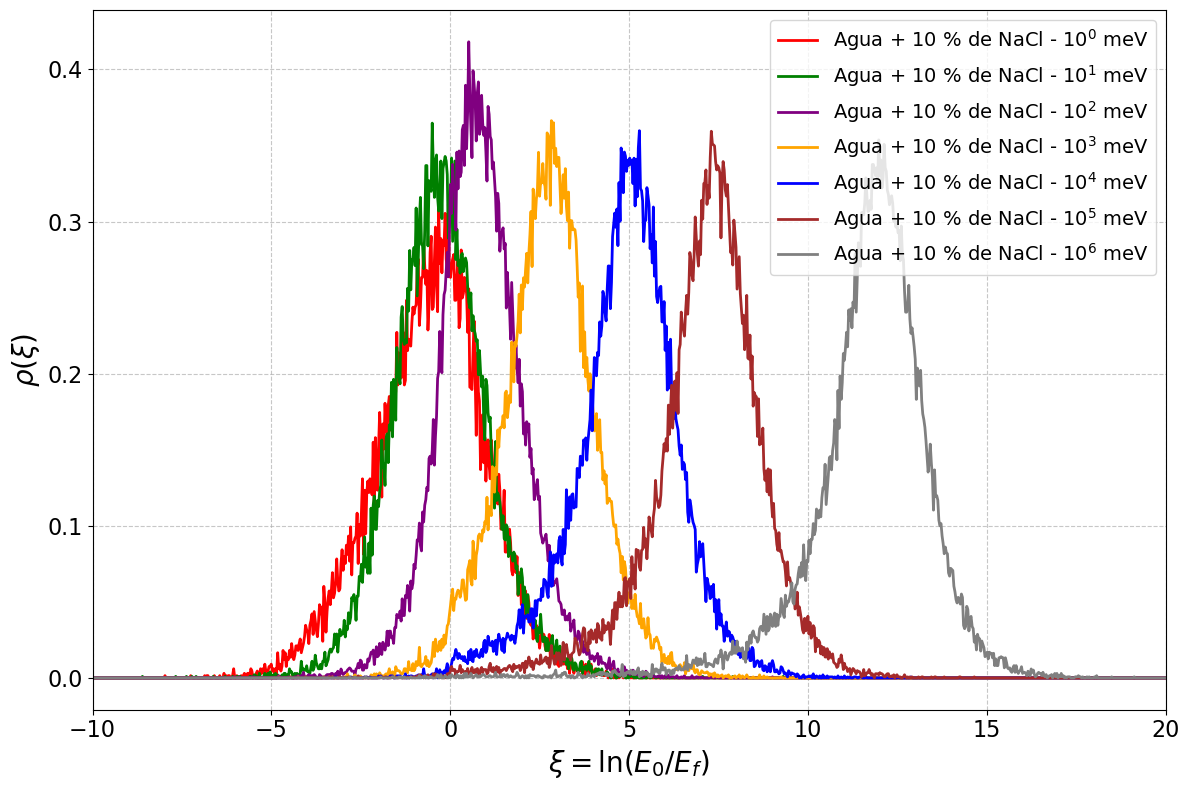

In [226]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]   # quitar NaN
    data = data[data != 0.0]       # quitar ceros

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular histograma
    counts, bins = np.histogram(data, bins=bins, range=range, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Graficar como línea
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, label=label)

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../1meV/Agua+10NaCl/cita-1meV-A-10NaCl.txt", "red",    "Agua + 10 % de NaCl - $10^{0}$ meV"),
    ("../10meV/Agua+10NaCl/cita-10meV-A-10NaCl.txt", "green", "Agua + 10 % de NaCl - $10^{1}$ meV"),
    ("../100meV/Agua+10NaCl/cita-100meV-A-10NaCl.txt", "purple","Agua + 10 % de NaCl - $10^{2}$ meV"),
    ("../1000meV/Agua+10NaCl/cita-1000meV-A-10NaCl.txt", "orange","Agua + 10 % de NaCl - $10^{3}$ meV"),
    ("../10000meV/Agua+10NaCl/cita-10000meV-A-10NaCl.txt", "blue","Agua + 10 % de NaCl - $10^{4}$ meV"),
    ("../100000meV/Agua+10NaCl/cita-100000meV-A-10NaCl.txt", "brown","Agua + 10 % de NaCl - $10^{5}$ meV"),
    ("../1000000meV/Agua+10NaCl/cita-1000000meV-A-10NaCl.txt", "grey","Agua + 10 % de NaCl - $10^{6}$ meV")
]

# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=1000, range=(-10,20), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)$", fontsize=20)
plt.ylabel(r"$\rho(\xi)$", fontsize=20)
plt.xlim(-10, 20)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=16)
plt.tick_params(axis='y', which='both', labelsize=16)
plt.legend(fontsize=14)

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-Agua-10NaCl.pdf", format="pdf")
plt.savefig("Cita-neutron-Agua-10NaCl.png", format="png")
plt.show()


Agua + 10 % de NaCl - $10^{0}$ meV: media = -0.5406, desviación estándar = 0.7775
Agua + 10 % de NaCl - $2.5$ meV: media = -0.3641, desviación estándar = 0.5820
Agua + 10 % de NaCl - $5$ meV: media = -0.2419, desviación estándar = 0.4436
Agua + 10 % de NaCl - $7$ meV: media = -0.1814, desviación estándar = 0.3838
Agua + 10 % de NaCl - $10^{1}$ meV: media = -0.1263, desviación estándar = 0.3419


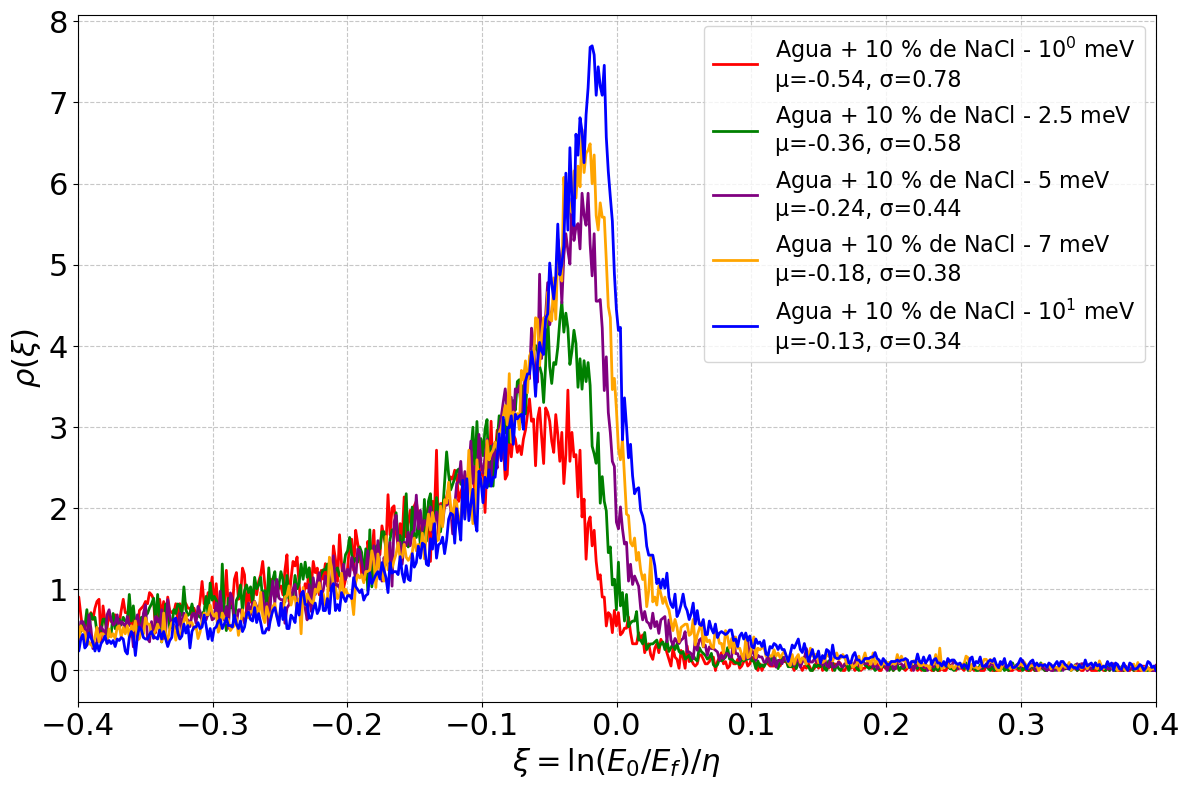

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]   # quitar NaN
    data = data[data != 0.0]       # quitar ceros

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular valores estadísticos
    mean_val = np.mean(data)
    std_val  = np.std(data)

    # Mostrar en consola
    print(f"{label}: media = {mean_val:.4f}, desviación estándar = {std_val:.4f}")

    # Calcular histograma
    counts, bins = np.histogram(data, bins=bins, range=range, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Graficar como línea
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, 
             label=f"{label}\nμ={mean_val:.2f}, σ={std_val:.2f}")

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../1meV/Agua+10NaCl/cita-A-10NaCl-1meV.txt", "red",    "Agua + 10 % de NaCl - $10^{0}$ meV"),
    ("../2.5meV/Agua+10NaCl/cita-A-10NaCl-2-5meV.txt", "green", "Agua + 10 % de NaCl - $2.5$ meV"),
    ("../5meV/Agua+10NaCl/cita-A-10NaCl-5meV.txt", "purple","Agua + 10 % de NaCl - $5$ meV"),
    ("../7meV/Agua+10NaCl/cita-A-10NaCl-7meV.txt", "orange","Agua + 10 % de NaCl - $7$ meV"),
    ("../10meV/Agua+10NaCl/cita-A-10NaCl-10meV.txt", "blue","Agua + 10 % de NaCl - $10^{1}$ meV")

]





# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=20000, range=(-10,20), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)/\eta$", fontsize=22)
plt.ylabel(r"$\rho(\xi)$", fontsize=22)
plt.xlim(-0.4, 0.4)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=22)
plt.tick_params(axis='y', which='both', labelsize=22)
plt.legend(fontsize=16, loc="upper right")

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-frios-10NaCl.pdf", format="pdf")
plt.savefig("Cita-neutron-frios-10NaCl.png", format="png")
plt.show()


Agua + 10 % de NaCl - $25$ meV: media = 0.0045, desviación estándar = 0.2598
Agua + 10 % de NaCl - $50$ meV: media = 0.0873, desviación estándar = 0.2615
Agua + 10 % de NaCl - $80$ meV: media = 0.1357, desviación estándar = 0.2793
Agua + 10 % de NaCl - $10^{2}$ meV: media = 0.1543, desviación estándar = 0.2854
Agua + 10 % de NaCl - $3\times 10^{2}$ meV: media = 0.2354, desviación estándar = 0.3270


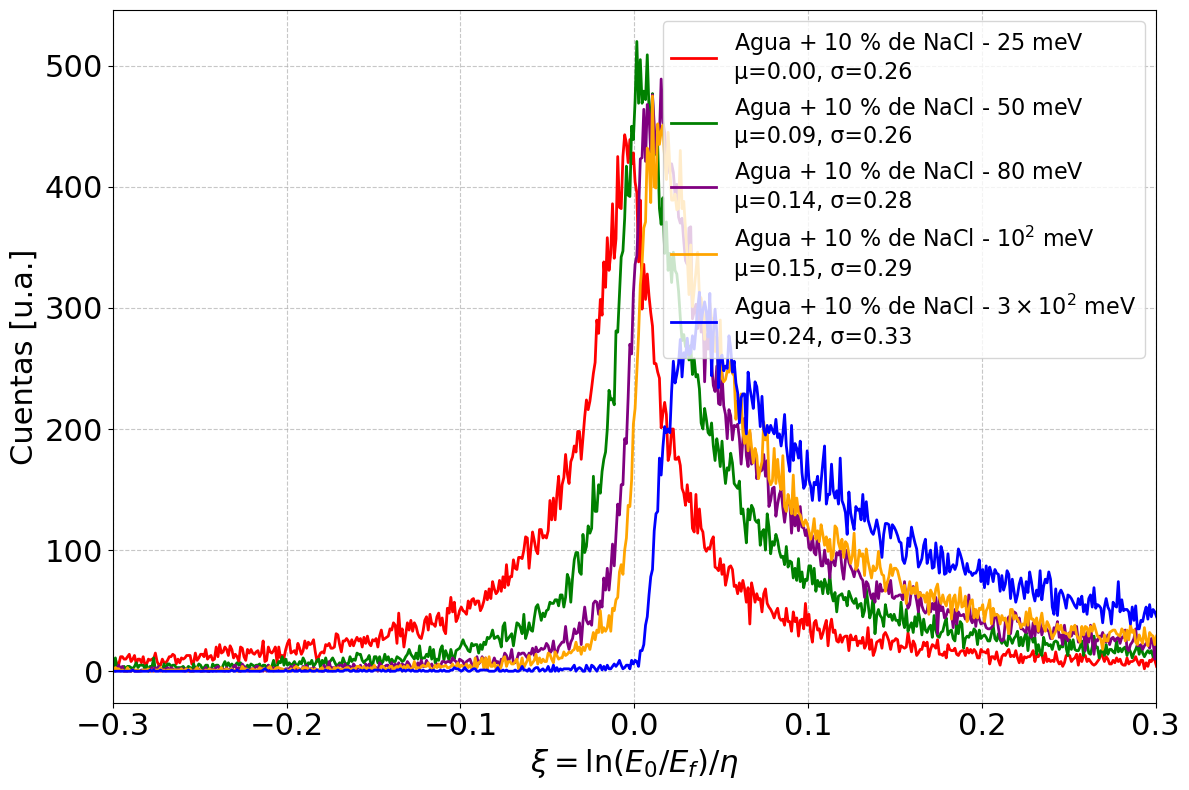

In [52]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt

# --- Función para graficar polígonos de frecuencia (sin densidad) ---
def plot_polygon_from_file(filename, bins=1000, range=(-10, 10), color="blue", label=""):
    # Leer archivo (ignora comentarios o líneas vacías)
    data = []
    with open(filename, "r") as f:
        for line in f:
            if line.strip() and not line.startswith("#"):
                try:
                    cols = line.split()
                    data.append(float(cols[0]))  # usar columna 1
                except:
                    continue
    data = np.array(data)

    # --- Filtrar: quitar nan y ceros ---
    data = data[~np.isnan(data)]
    data = data[data != 0.0]

    if len(data) == 0:
        print(f"⚠️ Archivo {filename} no tiene datos válidos después del filtrado.")
        return

    # Calcular valores estadísticos
    mean_val = np.mean(data)
    std_val  = np.std(data)

    # Mostrar en consola
    print(f"{label}: media = {mean_val:.4f}, desviación estándar = {std_val:.4f}")

    # Calcular histograma (SIN normalizar)
    counts, bins = np.histogram(data, bins=bins, range=range, density=False)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Graficar como polígono (línea continua)
    plt.plot(bin_centers, counts, linestyle='-', linewidth=2, color=color, 
             label=f"{label}\nμ={mean_val:.2f}, σ={std_val:.2f}")

# ============================
# Archivos a graficar
# ============================
archivos = [
    ("../25meV/Agua+10NaCl/cita-A-10NaCl-25meV.txt", "red",    "Agua + 10 % de NaCl - $25$ meV"),
    ("../50meV/Agua+10NaCl/cita-A-10NaCl-50meV.txt", "green", "Agua + 10 % de NaCl - $50$ meV"),
    ("../80meV/Agua+10NaCl/cita-A-10NaCl-80meV.txt", "purple","Agua + 10 % de NaCl - $80$ meV"),
    ("../100meV/Agua+10NaCl/cita-A-10NaCl-100meV.txt", "orange","Agua + 10 % de NaCl - $10^{2}$ meV"),
    ("../300meV/Agua+10NaCl/cita-A-10NaCl-300meV.txt", "blue","Agua + 10 % de NaCl - $3\\times 10^{2}$ meV")
]

# ============================
# Graficar todos en una sola figura
# ============================
plt.figure(figsize=(12,8))

for filename, color, label in archivos:
    plot_polygon_from_file(filename, bins=2000, range=(-1, 1), color=color, label=label)

# Etiquetas
plt.xlabel(r"$\xi = \ln\!\left(E_{0}/E_{f}\right)/\eta$", fontsize=22)
plt.ylabel("Cuentas [u.a.]", fontsize=22)
plt.xlim(-0.3, 0.3)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=22)
plt.tick_params(axis='y', which='both', labelsize=22)
plt.legend(fontsize=16, loc="upper right")

# Guardar
plt.tight_layout()
plt.savefig("Cita-neutron-termicos-A-10NaCl-poligono.pdf", format="pdf")
plt.savefig("Cita-neutron-termicos-A-10NaCl-poligono.png", format="png")
plt.show()


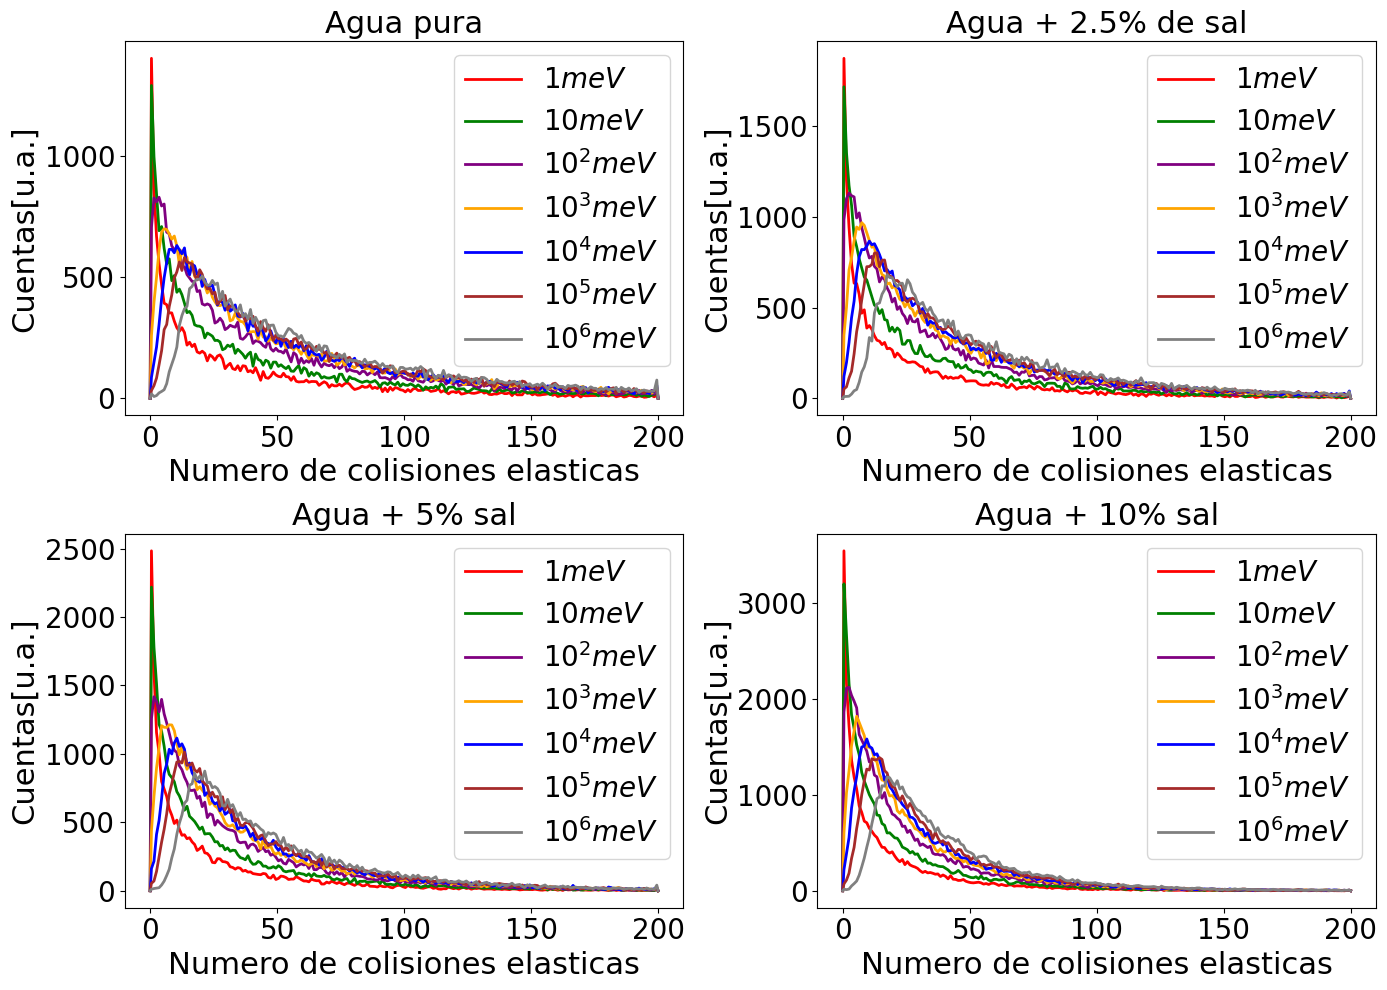

In [242]:
import matplotlib.pyplot as plt
import numpy as np

# Definir número de bins y rango
numero_bins = 200
inicio, fin = 0, 200

# Función para calcular y graficar polígonos de frecuencia como línea continua
#def plot_polygon(ax, data, color, label):
#    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
#    bin_centers = (bins[:-1] + bins[1:]) / 2  
#    ax.plot(bin_centers, counts, linestyle='-', color=color, label=label, linewidth=2)

def plot_polygon(ax, data, color, label):
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    bin_centers = (bins[:-1] + bins[1:]) / 2  
    
    # Insertar extremos en 0 y 200 con valor 0
    x = np.concatenate(([inicio], bin_centers, [fin]))
    y = np.concatenate(([0], counts, [0]))
    
    ax.plot(x, y, linestyle='-', color=color, label=label, linewidth=2)



# Crear figura con 4 subgráficos en una matriz 2x2
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Definir los conjuntos de datos y títulos de cada subgráfico
datos = [
    ([
        datos_n_AP_1meV, datos_n_AP_10meV, datos_n_AP_100meV,
        datos_n_AP_1000meV, datos_n_AP_10000meV, datos_n_AP_100000meV, datos_n_AP_1000000meV
    ], "Agua pura"),
    ([
        datos_n_A_25NaCl_1meV, datos_n_A_25NaCl_10meV, datos_n_A_25NaCl_100meV,
        datos_n_A_25NaCl_1000meV, datos_n_A_25NaCl_10000meV, datos_n_A_25NaCl_100000meV, datos_n_A_25NaCl_1000000meV
    ], "Agua + 2.5% de sal"),
    ([
        datos_n_A_5NaCl_1meV, datos_n_A_5NaCl_10meV, datos_n_A_5NaCl_100meV,
        datos_n_A_5NaCl_1000meV, datos_n_A_5NaCl_10000meV, datos_n_A_5NaCl_100000meV, datos_n_A_5NaCl_1000000meV
    ], "Agua + 5% sal"),
    ([
        datos_n_A_10NaCl_1meV, datos_n_A_10NaCl_10meV, datos_n_A_10NaCl_100meV,
        datos_n_A_10NaCl_1000meV, datos_n_A_10NaCl_10000meV, datos_n_A_10NaCl_100000meV, datos_n_A_10NaCl_1000000meV
    ], "Agua + 10% sal")
]

colores = ['red', 'green', 'purple', 'orange', 'blue', 'brown', 'grey']
#labels = ['1 meV', '10 meV', '100 meV', '1000 meV', '10000 meV', '100000 meV', '1000000 meV']
labels = ['$1 meV$', '$10 meV$', '$10^2 meV$', '$10^3 meV$', '$10^4 meV$', '$10^5 meV$', '$10^6 meV$']

# Graficar en cada subgráfico
for ax, (data_sets, title) in zip(axs.flatten(), datos):
    for i, (data, color) in enumerate(zip(data_sets, colores)):
        plot_polygon(ax, data, color=color, label=f'{labels[i]}')
    
    ax.set_title(title, fontsize=22)
    ax.set_xlabel('Numero de colisiones elasticas', fontsize=22)
    ax.set_ylabel('Cuentas[u.a.]', fontsize=22)
    #ax.set_yscale('log')  # Escala logarítmica
    #ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(fontsize=20)
    ax.tick_params(axis='both', which='major', labelsize=20)  # Ajusta tamaño de los números en los ejes

# Ajustar diseño y guardar la figura
plt.tight_layout()
plt.savefig('Matriz_NC_Total_Agua_NaCl.jpg', format='jpg')
plt.savefig('Matriz_NC_Total_Agua_NaCl.pdf', format='pdf')
plt.show()


In [77]:
import matplotlib.pyplot as plt
import numpy as np
num_bins_n_AP = int(math.sqrt(len(datos_n_AP)))
num_bins_n_25NaCl = int(math.sqrt(len(datos_n_25NaCl)))
num_bins_n_5NaCl = int(math.sqrt(len(datos_n_5NaCl)))
num_bins_n_10NaCl = int(math.sqrt(len(datos_n_10NaCl)))
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].hist(datos_n_AP, bins=100,histtype='step', lw=1.0,edgecolor='red', log=True)
#parametros_histograma_1 = {'min': -5, 'max': 5, 'bins': 20, 'color': 'blue', 'label': 'Histograma 1'}
axs[0, 0].hist(datos_n_AP, bins=num_bins_n_AP,histtype='step', lw=1.0,edgecolor='red', log=True)
axs[0, 0].set_title('Agua pura')
axs[0, 0].set_xlabel('Número de Foto-electrones')
axs[0, 0].set_ylabel('Cuentas')
axs[0, 0].grid(True)
num_entries = len(datos_n_AP)
mean = sum(datos_n_AP) / num_entries
std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_AP) / num_entries)
info_text = f'Agua Pura + N \nN° entradas: {num_entries}'
axs[0, 0].text(0.5, 0.5, f'N° entradas: {num_entries}', fontsize=12, ha='center', va='center', transform=axs[0, 0].transAxes)

axs[0, 1].hist(datos_n_25NaCl, bins=num_bins_n_25NaCl,histtype='step', lw=1.0,edgecolor='green', log=True)
axs[0, 1].set_title('Agua pura + 2.5 % de sal')
axs[0, 1].set_xlabel('Número de Foto-electrones')
axs[0, 1].set_ylabel('Cuentas')
axs[0, 1].grid(True)
num_entries = len(datos_n_25NaCl)
mean = sum(datos_n_25NaCl) / num_entries
std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_25NaCl) / num_entries)
axs[0, 1].text(0.5, 0.5, f'N° entradas: {num_entries}', fontsize=12, ha='center', va='center', transform=axs[0, 1].transAxes)


axs[1, 0].hist(datos_n_5NaCl, bins=num_bins_n_5NaCl,histtype='step', lw=1.0,edgecolor='purple', log=True)
axs[1, 0].set_title('Agua pura + 5 % de sal')
axs[1, 0].set_xlabel('Número de Foto-electrones')
axs[1, 0].set_ylabel('Cuentas')
axs[1, 0].grid(True)
num_entries = len(datos_n_5NaCl)
mean = sum(datos_n_5NaCl) / num_entries
std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_5NaCl) / num_entries)
axs[1, 0].text(0.5, 0.5, f'N° entradas: {num_entries}', fontsize=12, ha='center', va='center', transform=axs[1, 0].transAxes)


axs[1, 1].hist(datos_n_10NaCl, bins=num_bins_n_10NaCl,histtype='step', lw=1.0,edgecolor='orange', log=True)
axs[1, 1].set_title('Agua pura + 10 % de sal')
axs[1, 1].set_xlabel('Número de Foto-electrones')
axs[1, 1].set_ylabel('Cuentas')
axs[1, 1].grid(True)
num_entries = len(datos_n_10NaCl)
mean = sum(datos_n_10NaCl) / num_entries
std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)
axs[1, 1].text(0.5, 0.5, f'N° entradas: {num_entries}', fontsize=12, ha='center', va='center', transform=axs[1, 1].transAxes)
pdf_filename_stat_charge = 'Carga_Total_Agua_10NaCl.pdf'
plt.savefig(pdf_filename_stat_charge, format='pdf')
plt.savefig('Histogramas-Carga-Total_Agua-10NaCl.jpg', format='jpg')
#plt.tight_layout()
plt.show()


NameError: name 'datos_n_AP' is not defined

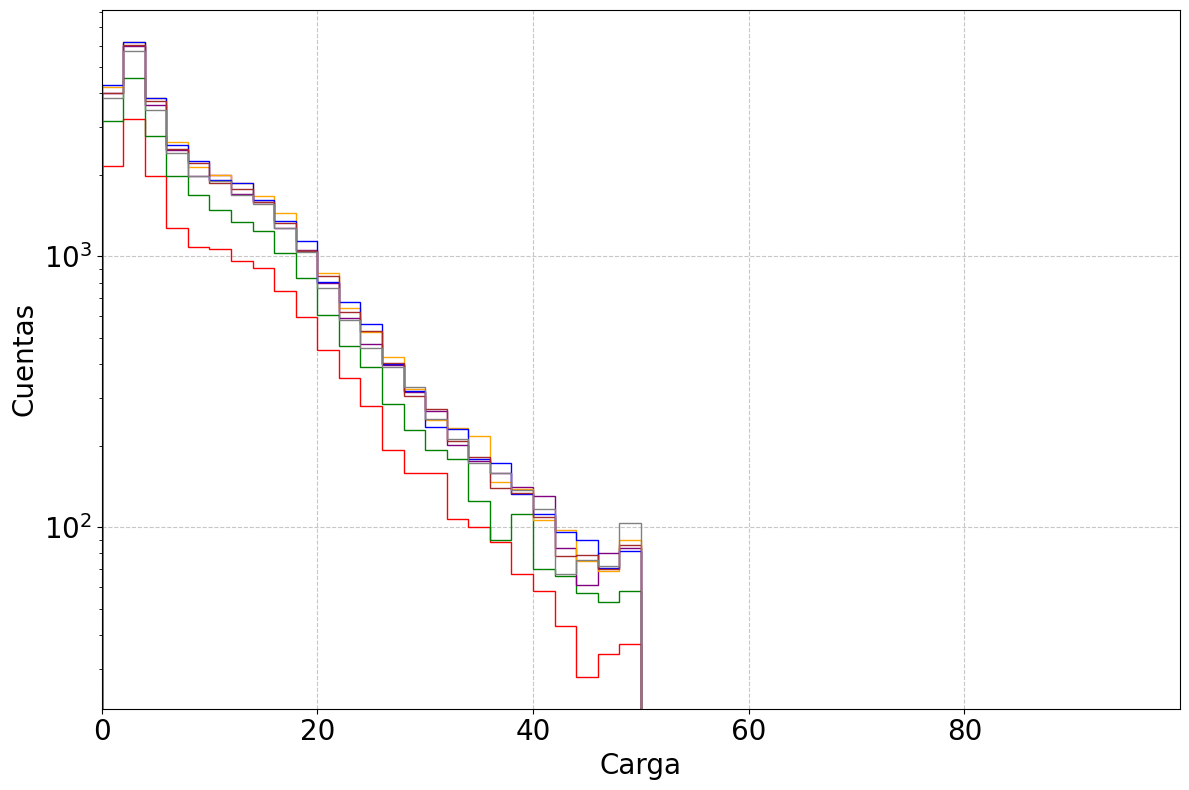

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
num_bins_n_A_10NaCl_1meV = int(math.sqrt(len(datos_n_A_10NaCl_1meV)))
num_bins_n_A_10NaCl_10meV = int(math.sqrt(len(datos_n_A_10NaCl_10meV)))
num_bins_n_A_10NaCl_100meV = int(math.sqrt(len(datos_n_A_10NaCl_100meV)))
num_bins_n_A_10NaCl_1000meV = int(math.sqrt(len(datos_n_A_10NaCl_1000meV)))
num_bins_n_A_10NaCl_10000meV = int(math.sqrt(len(datos_n_A_10NaCl_10000meV)))
num_bins_n_A_10NaCl_100000meV = int(math.sqrt(len(datos_n_A_10NaCl_100000meV)))
num_bins_n_A_10NaCl_1000000meV = int(math.sqrt(len(datos_n_A_10NaCl_1000000meV)))

numero_bins=25
inicio=0
fin=50
plt.figure(figsize=(12, 8))
plt.hist(datos_n_A_10NaCl_1meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='red', alpha=1.0, log=True)
#num_entries = len(datos_n_AP)
#mean = sum(datos_n_AP) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_AP) / num_entries)
#stats_text_charge = f'Agua Pura\n Entradas: {num_entries}\nMean: {mean:.2f}\nRMS: {std_dev:.2f}'
#stats_text_charge = f'Agua Pura\nEntradas: {num_entries}'
#plt.text(0.83, 0.89, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='red', alpha=0.5))
#plt.text(0.78, 0.91, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')
# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.93  # Posición de la línea en el eje y (ligeramente debajo del texto)
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='red', linewidth=4)

plt.hist(datos_n_A_10NaCl_10meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='green', alpha=1.0, log=True)
#num_entries = len(datos_n_25NaCl)
#mean = sum(datos_n_25NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_25NaCl) / num_entries)
#stats_text_charge = f'Agua + 2.5 % de sal\nEntradas: {num_entries}'
#plt.text(0.83, 0.83, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='green', alpha=0.5))
#plt.text(0.78, 0.83, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')
# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.85  # Posición de la línea en el eje y (ligeramente debajo del texto)

# Dibujar la línea naranja
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='green', linewidth=4)

plt.hist(datos_n_A_10NaCl_100meV,bins=numero_bins, histtype='step', range=(inicio, fin), lw=1.0,edgecolor='purple', log=True)
#num_entries = len(datos_n_5NaCl)
#mean = sum(datos_n_5NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_5NaCl) / num_entries)
#stats_text_charge = f'Agua + 5 % de sal \nEntradas: {num_entries}'
#plt.text(0.78, 0.75, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')
# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.77  # Posición de la línea en el eje y (ligeramente debajo del texto)

# Dibujar la línea naranja
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='purple', linewidth=4)


#plt.text(0.80, 0.77, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='purple', alpha=0.5))


plt.hist(datos_n_A_10NaCl_1000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='orange', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)

plt.hist(datos_n_A_10NaCl_10000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='blue', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)


plt.hist(datos_n_A_10NaCl_100000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='brown', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)
#stats_text_charge = f'Agua + 10 % de sal\nEntradas: {num_entries}'

plt.hist(datos_n_A_10NaCl_1000000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='grey', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)
#stats_text_charge = f'Agua + 10 % de sal\nEntradas: {num_entries}'

# Agregar el texto
#plt.text(0.78, 0.68, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')

# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.71  # Posición de la línea en el eje y (ligeramente debajo del texto)

# Dibujar la línea naranja
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='orange', linewidth=4)

# Crear segmentos de línea para las leyendas
#linea_color_1 = Line2D([0], [0], color='red', lw=2)
#linea_color_2 = Line2D([0], [0], color='green', lw=2)
#linea_color_3 = Line2D([0], [0], color='purple', lw=2)
#linea_color_4 = Line2D([0], [0], color='orange', lw=2)

# Agregar leyendas una debajo de otra
#plt.legend([linea_color_1, linea_color_2, linea_color_3, linea_color_4],
#           ['Agua pura', 'Agua + 2.5 % de sal', 'Agua + 5 % de sal', 'Agua + 10 % de sal'],
#           loc='upper right',fontsize=14)


#stats_text_charge = f'Agua + 10 % de sal\nEntradas: {num_entries}'
#plt.text(0.83, 0.71, stats_text_charge, transform=plt.gca().transAxes,fontsize=14, fontweight='bold', fontstyle='italic',bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))


#plt.text(0.83, 0.71, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))


#plt.hist(datos_n_25NaCl,bins=num_bins, histtype='step', range=(inicio, fin), color='orange', alpha=0.9, log=True)
plt.title('')
plt.xlabel('Carga', fontsize=20)
plt.ylabel('Cuentas', fontsize=20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=20)  # Tics mayores
plt.xlim(0, 100)
plt.xticks(np.arange(0, 100, 20))

plt.grid(True)
#num_entries = len(datos_n_25NaCl)
#mean = sum(datos_n_25NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_25NaCl) / num_entries)
#stats_text_charge = f'Agua con N. a 500 MeV\nEntradas: {num_entries}\nMean: {mean:.2f}\nRMS: {std_dev:.2f}'
#plt.text(0.83, 0.33, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))

pdf_filename_diff_25 = 'Comparacion-Histogramas-carga-Neutrones-Exterior-TA-80H.pdf'
plt.savefig('Comparacion-Histogramas-carga-Neutrones-Exterior-TA-80H.jpg', format='jpg')
plt.savefig(pdf_filename_diff_25, format='pdf')
plt.tight_layout()
plt.show()


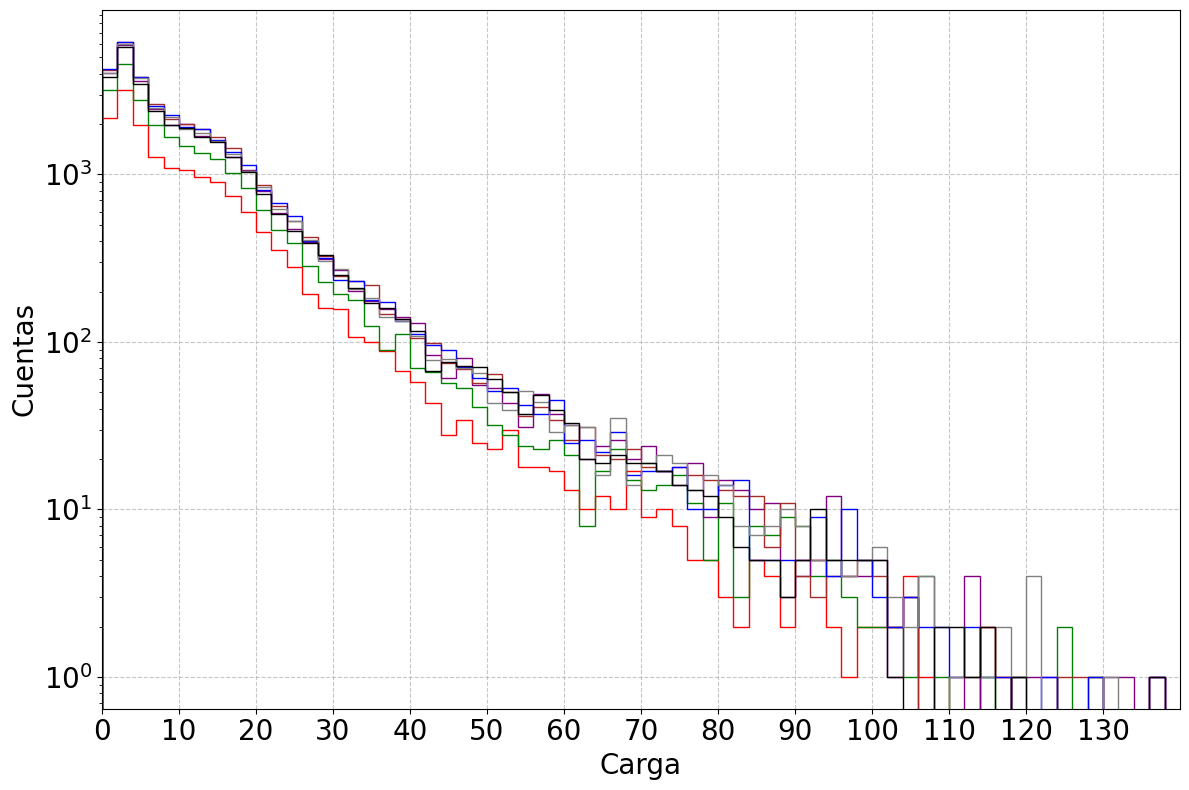

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

num_bins_n_A_10NaCl_1meV = int(math.sqrt(len(datos_n_A_10NaCl_1meV)))
num_bins_n_A_10NaCl_10meV = int(math.sqrt(len(datos_n_A_10NaCl_10meV)))
num_bins_n_A_10NaCl_100meV = int(math.sqrt(len(datos_n_A_10NaCl_100meV)))
num_bins_n_A_10NaCl_1000meV = int(math.sqrt(len(datos_n_A_10NaCl_1000meV)))
num_bins_n_A_10NaCl_10000meV = int(math.sqrt(len(datos_n_A_10NaCl_10000meV)))
num_bins_n_A_10NaCl_100000meV = int(math.sqrt(len(datos_n_A_10NaCl_100000meV)))
num_bins_n_A_10NaCl_1000000meV = int(math.sqrt(len(datos_n_A_10NaCl_1000000meV)))


#num_bins_n_10NaCl = int(math.sqrt(len(datos_n_10NaCl)))

numero_bins=100
inicio=0
fin=200
plt.figure(figsize=(12, 8))

plt.hist(datos_n_A_10NaCl_1meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='red', alpha=1.0, log=True)
#num_entries = len(datos_n_AP)
#mean = sum(datos_n_AP) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_AP) / num_entries)
#stats_text_charge = f'Agua Pura\n Entradas: {num_entries}\nMean: {mean:.2f}\nRMS: {std_dev:.2f}'
#stats_text_charge = f'Agua Pura\nEntradas: {num_entries}'
#plt.text(0.83, 0.89, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='red', alpha=0.5))
#plt.text(0.78, 0.91, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')
# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.93  # Posición de la línea en el eje y (ligeramente debajo del texto)
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='red', linewidth=4)

plt.hist(datos_n_A_10NaCl_10meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='green', alpha=1.0, log=True)
#num_entries = len(datos_n_25NaCl)
#mean = sum(datos_n_25NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_25NaCl) / num_entries)
#stats_text_charge = f'Agua + 2.5 % de sal\nEntradas: {num_entries}'
#plt.text(0.83, 0.83, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='green', alpha=0.5))
#plt.text(0.78, 0.83, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')
# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.85  # Posición de la línea en el eje y (ligeramente debajo del texto)

# Dibujar la línea naranja
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='green', linewidth=4)

plt.hist(datos_n_A_10NaCl_100meV,bins=numero_bins, histtype='step', range=(inicio, fin), lw=1.0,edgecolor='purple', log=True)
#num_entries = len(datos_n_5NaCl)
#mean = sum(datos_n_5NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_5NaCl) / num_entries)
#stats_text_charge = f'Agua + 5 % de sal \nEntradas: {num_entries}'
#plt.text(0.78, 0.75, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')
# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.77  # Posición de la línea en el eje y (ligeramente debajo del texto)

# Dibujar la línea naranja
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='purple', linewidth=4)


#plt.text(0.80, 0.77, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='purple', alpha=0.5))


plt.hist(datos_n_A_10NaCl_1000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='brown', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)


plt.hist(datos_n_A_10NaCl_10000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='blue', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)


plt.hist(datos_n_A_10NaCl_100000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='grey', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)


plt.hist(datos_n_A_10NaCl_1000000meV, bins=numero_bins, histtype='step', range=(inicio, fin), color='black', alpha=1.0, log=True)
#num_entries = len(datos_n_10NaCl)
#mean = sum(datos_n_10NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_10NaCl) / num_entries)

#stats_text_charge = f'Agua + 10 % de sal\nEntradas: {num_entries}'

# Agregar el texto
#plt.text(0.78, 0.68, stats_text_charge, transform=plt.gca().transAxes, fontsize=14, color='black')

# Coordenadas de la línea (ajustar según sea necesario)
#x_start, x_end = 0.75, 0.76  # Posición en el eje x (en coordenadas de la figura)
#y_line = 0.71  # Posición de la línea en el eje y (ligeramente debajo del texto)

# Dibujar la línea naranja
#plt.plot([x_start, x_end], [y_line, y_line], transform=plt.gca().transAxes,  color='orange', linewidth=4)

# Crear segmentos de línea para las leyendas
#linea_color_1 = Line2D([0], [0], color='red', lw=2)
#linea_color_2 = Line2D([0], [0], color='green', lw=2)
#linea_color_3 = Line2D([0], [0], color='purple', lw=2)
#linea_color_4 = Line2D([0], [0], color='orange', lw=2)

# Agregar leyendas una debajo de otra
#plt.legend([linea_color_1, linea_color_2, linea_color_3],['Agua + 2.5 % de sal a 100 eV', 'Agua + 2.5 % de sal a 1KeV', 'Agua + 2.5 % de sal a 10eV'],loc='upper right',fontsize=14)


# Agregar leyendas una debajo de otra
#plt.legend([linea_color_1, linea_color_2, linea_color_3, linea_color_4],
#           ['Agua pura', 'Agua + 2.5 % de sal', 'Agua + 5 % de sal', 'Agua + 10 % de sal'],
#           loc='upper right',fontsize=14)


#stats_text_charge = f'Agua + 10 % de sal\nEntradas: {num_entries}'
#plt.text(0.83, 0.71, stats_text_charge, transform=plt.gca().transAxes,fontsize=14, fontweight='bold', fontstyle='italic',bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))


#plt.text(0.83, 0.71, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))


#plt.hist(datos_n_25NaCl,bins=num_bins, histtype='step', range=(inicio, fin), color='orange', alpha=0.9, log=True)
plt.title('')
plt.xlabel('Carga', fontsize=20)
plt.ylabel('Cuentas', fontsize=20)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=20)  # Tics mayores
plt.xlim(0, 140)
plt.xticks(np.arange(0, 140, 10))

plt.grid(True)
#num_entries = len(datos_n_25NaCl)
#mean = sum(datos_n_25NaCl) / num_entries
#std_dev = math.sqrt(sum((x - mean) ** 2 for x in datos_n_25NaCl) / num_entries)
#stats_text_charge = f'Agua con N. a 500 MeV\nEntradas: {num_entries}\nMean: {mean:.2f}\nRMS: {std_dev:.2f}'
#plt.text(0.83, 0.33, stats_text_charge, transform=plt.gca().transAxes,bbox=dict(boxstyle='round', facecolor='orange', alpha=0.5))

pdf_filename_diff_25 = 'Comparacion-Histogramas-carga-Neutrones-Exterior-TA-80H.pdf'
plt.savefig('Comparacion-Histogramas-carga-Neutrones-Exterior-TA-80H.jpg', format='jpg')
plt.savefig(pdf_filename_diff_25, format='pdf')
plt.tight_layout()
plt.show()


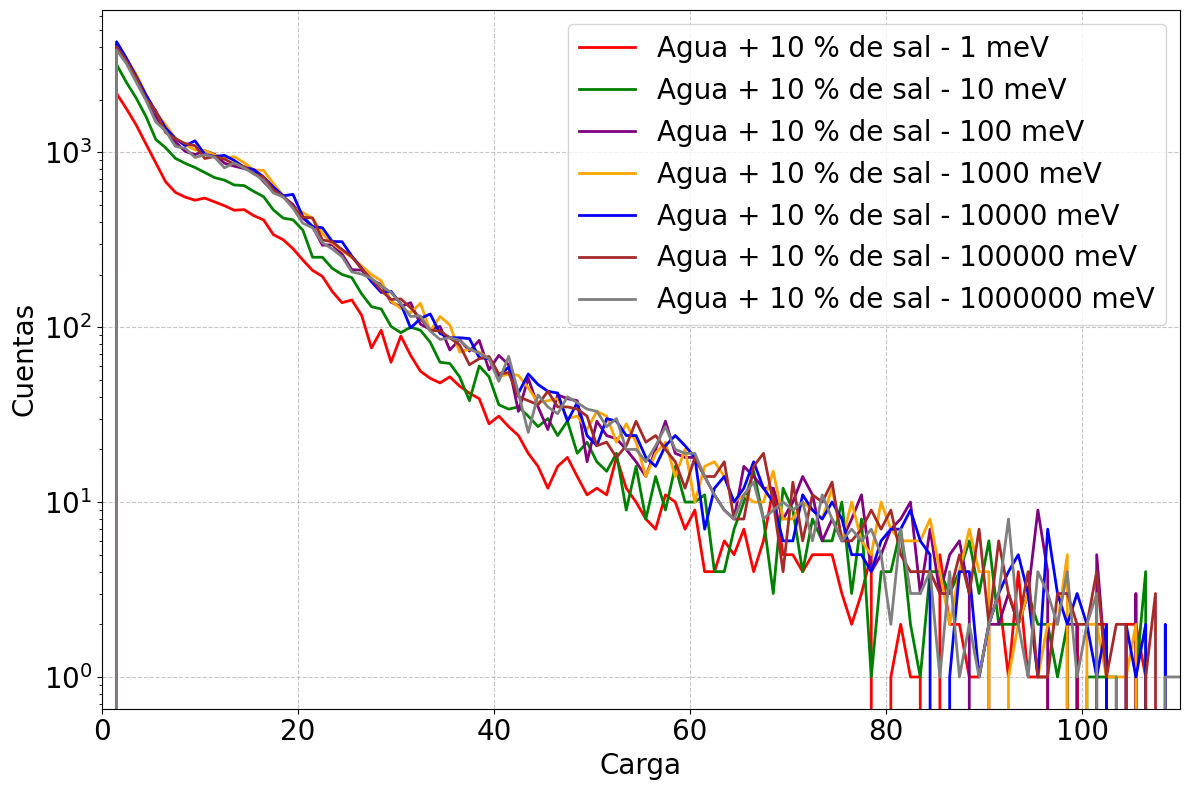

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.lines import Line2D

# Definir número de bins y rango
numero_bins = 200
inicio, fin = 0, 200

# Función para calcular y graficar polígonos de frecuencia como línea continua
def plot_polygon(data, color, label):
    # Obtener histogram data
    counts, bins = np.histogram(data, bins=numero_bins, range=(inicio, fin))
    
    # Calcular el punto medio de cada bin
    bin_centers = (bins[:-1] + bins[1:]) / 2  
    
    # Graficar solo la línea continua (sin puntos)
    plt.plot(bin_centers, counts, linestyle='-', color=color, label=label, linewidth=2)

# Crear figura
plt.figure(figsize=(12, 8))

# Graficar los datos como polígonos de frecuencia (líneas continuas)
plot_polygon(datos_n_A_10NaCl_1meV, color='red', label='Agua + 10 % de sal - 1 meV')
plot_polygon(datos_n_A_10NaCl_10meV, color='green', label='Agua + 10 % de sal - 10 meV')
plot_polygon(datos_n_A_10NaCl_100meV, color='purple', label='Agua + 10 % de sal - 100 meV')
plot_polygon(datos_n_A_10NaCl_1000meV, color='orange', label='Agua + 10 % de sal - 1000 meV')
plot_polygon(datos_n_A_10NaCl_10000meV, color='blue', label='Agua + 10 % de sal - 10000 meV')
plot_polygon(datos_n_A_10NaCl_100000meV, color='brown', label='Agua + 10 % de sal - 100000 meV')
plot_polygon(datos_n_A_10NaCl_1000000meV, color='grey', label='Agua + 10 % de sal - 1000000 meV')

# Agregar etiquetas y formato
plt.xlabel('Carga', fontsize=20)
plt.ylabel('Cuentas', fontsize=20)
plt.yscale('log')  # Escala logarítmica
plt.xlim(0, 110)
plt.xticks(np.arange(0, 110, 20))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=20)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=20)  # Tics mayores
# Agregar leyenda
plt.legend(fontsize=20)

# Guardar y mostrar
plt.tight_layout()
plt.savefig('Cambio-Carga-Agua-10NaCl.jpg', format='jpg')
plt.savefig('Cambio-Carga-Agua-10NaCl.pdf', format='pdf')
plt.show()
